In [1]:
!pip install category_encoders
!pip install dask
import os, random, io
import numpy as np, pandas as pd, dask.dataframe as dd
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.collections as mcoll, matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from matplotlib.figure import Figure
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    matthews_corrcoef, log_loss
)

In [2]:
'''from google.colab import drive
drive.mount('/content/drive', force_remount=True)'''

"from google.colab import drive\ndrive.mount('/content/drive', force_remount=True)"

# **CIS 5450 Final Project** 
# **User-Level Purchase Prediction from E-Commerce Behavioral Logs**
*YiFan Cai, YiRan Hu, Shanae Obi, Yuanqi Zhen*

# Part 1: Introduction


### Problem Definition

In this project, we address the problem of predicting user purchase behavior on an e-commerce platform. Specifically, we formulate this task as a binary classification problem at the user level, where the objective is to estimate the probability that a given user will make a purchase within a specified time window based on their historical interaction data.

The prediction is constructed from large-scale behavioral logs that record user activities such as product views, cart additions, and purchases. These interaction signals provide valuable information about user engagement and intent, forming the basis for predictive modeling.

### Motivation

Accurately modeling user purchase behavior is a fundamental problem in modern e-commerce systems, with direct implications for personalized recommendation, targeted advertising, and customer lifecycle management. Identifying users with high purchase intent enables platforms to optimize product exposure, improve conversion rates, and allocate marketing resources more effectively.

Despite its practical importance, this task presents several challenges. First, user behavior is highly imbalanced, as only a small fraction of users complete purchases. Second, user interactions are heterogeneous and multi-modal, consisting of different action types with varying semantic meanings and predictive value. Third, large-scale real-world datasets often contain noise, missing values, and high-cardinality categorical variables, which complicate feature representation and model learning.

### Approach Overview

To address these challenges, we construct **a three-stage progressive feature enrichment framework** that leverages both aggregated user-level statistics and fine-grained interaction signals. Starting from a baseline representation, we progressively incorporate richer behavioral and contextual features, allowing us to systematically evaluate their impact on predictive performance.

### Key Contributions

The main contributions of this project are as follows:

- We propose a structured feature engineering framework that integrates user-level aggregation with event-level behavioral modeling.
- We design a comprehensive set of features capturing behavioral intensity, temporal dynamics, and interaction diversity.
- We demonstrate the effectiveness of progressively incorporating richer feature representations in improving predictive performance.
- We provide an empirical analysis of how different feature types interact with model architectures in large-scale e-commerce prediction tasks.

## Data Availability and Reproducibility

For ease of use within this notebook environment, the dataset used in this project (The original one, and three processed versions) has been hosted externally on Hugging Face:

- Dataset: https://huggingface.co/datasets/skpy/E_Commerce_Behavioral_Analysis/tree/main  

This allows direct access without requiring local file setup, enabling smoother execution and reproducibility of the data processing pipeline.

The full implementation of the project is available on GitHub:

- Repository: https://github.com/caiyf03/Ecommerce-purchase-prediction

The repository contains a modular implementation based on standalone Python scripts, covering data preprocessing, feature engineering, and model training. Compared to the notebook, this script-based structure provides better support for reproducibility, maintainability, and scalable experimentation.

- Project Introduction Video: https://drive.google.com/file/d/1P2BgPxwgRA_KViHkEOCndbypJG2Z2BIP/view?usp=sharing 

#  Part 2:  Data Loading & Preprocessing

**Orginal Dataset**

The dataset used in this project is the REES46 Multi-Category Store e-commerce behavioral dataset (October 2019),  sourced from Kaggle (https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/data) which contains approximately 42 million user interaction records.


Each row corresponds to a single user action and includes key fields such as:
- `event_time`: timestamp of the interaction  
- `event_type`: type of action (view, cart, remove_from_cart, purchase)  
- `product_id`, `category_id`, `category_code`: product and category information  
- `brand`: product brand (may contain missing values)  
- `price`: price at the time of interaction  
- `user_id`: unique user identifier  
- `user_session`: session identifier  

The dataset contains a mix of numerical and categorical features, as well as temporal information, providing a comprehensive view of user behavior.

**Why This Dataset is Suitable**

This dataset is particularly well-suited for our project for several reasons.

- it directly aligns with our prediction objective. Since the dataset explicitly records purchase events, it allows us to naturally define a binary classification task at the user level (i.e., whether a user makes a purchase).

- the dataset captures the full user interaction funnel, including views, cart additions, and purchases. This enables us to model user behavior across different stages of engagement and construct meaningful features such as conversion rates and activity intensity.

- the presence of timestamps allows us to incorporate temporal patterns into our features, such as activity time distribution and behavioral consistency.

- the dataset includes hierarchical product category information (`category_code`), which can be leveraged for both feature engineering and potential embedding-based models.

- the large scale of the dataset (over 40 million events and 3 million users) makes it realistic and representative of real-world e-commerce systems. This provides a strong foundation for building and evaluating machine learning models under practical conditions.


In [3]:
# -----------------------------------------------------------------------------
# Execution Control Switch
#
# To improve usability and avoid unnecessary recomputation, we introduce a
# boolean flag `Display` as a control switch for expensive data processing steps.
#
# When `Display = True`, the code will execute normally and regenerate the
# corresponding outputs (e.g., feature tables).
#
# When `Display = False`, these steps will be skipped, allowing the notebook to
# run quickly without repeatedly processing large datasets.
# -----------------------------------------------------------------------------

Display = True

In [4]:
if Display:
    import pandas as pd

    # Load compressed dataset
    df = pd.read_csv(r"F:\CIS5450\2019-Oct.csv.gz", compression='gzip')

    # Preview structure
    df.head()

    # Basic info
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


# 2.2 User-Level Data Processing Workflow

**Overview**

This section describes the user-level data processing pipeline applied to the REES46 Multi-Category Store e-commerce behavioral dataset (October 2019). The goal of this pipeline is to transform the raw event-level data into a structured dataset where each row corresponds to a unique user, enabling downstream classification tasks such as purchase prediction.

The raw dataset contains approximately 42 million event records. Through aggregation, this pipeline produces a user-level dataset with approximately 3 million rows, significantly reducing data size while preserving essential behavioral information.


**Processing Workflow**

The pipeline follows a modular aggregation design to construct user-level features.

First, three binary indicator variables (`is_view`, `is_cart`, `is_purchase`) are created based on the event type. These indicators enable straightforward aggregation without conditional logic.

Next, the dataset is grouped by `user_id` to compute core behavioral statistics, including total views, total carts, total purchases, average price, and maximum price. A binary label `purchased` is then defined based on whether the user has at least one purchase event. Additionally, total activity (`total_events`) is computed as the sum of all event counts.

To capture conversion behavior, smoothed conversion rates are introduced. Specifically, cart rate and purchase rate are computed using Laplace smoothing (+1 in the denominator), which prevents division by zero and ensures numerical stability for users with no view events.

Further feature engineering is conducted through separate aggregation modules. Temporal features are extracted from timestamps, including average activity hour, standard deviation of activity hour, and number of distinct active days. Diversity features capture the number of unique product categories and products interacted with by each user. Additional price statistics, such as minimum price and price standard deviation, describe the user's browsing price range.

Each feature group is computed independently and merged back into the main user-level table. This modular design improves interpretability and reduces the risk of unintended data leakage during feature construction.

Finally, several binary behavioral flags are introduced, including whether the user has ever added items to cart, whether the user is highly active, and whether the user browses across multiple categories.

Missing values are filled with zero, which is consistent with the absence of observed behavior for most aggregated features.

**Feature Summary**

The final dataset contains features across multiple groups:

- Event counts: total_views, total_carts, total_purchases, total_events  
- Conversion behavior: cart_rate, purchase_rate  
- Temporal patterns: avg_hour, hour_std, active_days  
- Diversity: num_categories, num_products  
- Price behavior: avg_price, max_price, min_price, price_std  
- Binary flags: has_carted, high_activity, multi_category  

The resulting user-level dataset provides a compact and information-rich representation of user behavior and serves as the primary input for downstream machine learning models. 

To ensure the validity of the predictive modeling, feature selection and construction will be carefully controlled in subsequent sections to avoid potential data leakage.

In [5]:
if not display:
    import pandas as pd
    df = pd.read_csv(r"F:\CIS5450\2019-Oct.csv.gz",)

    # convert time
    df["event_time"] = pd.to_datetime(df["event_time"])

    # drop missing values (simple version)
    df = df.dropna(subset=["event_type", "product_id", "price", "user_id"])

    # 1. Indicator columns
    df['is_view'] = (df['event_type'] == 'view').astype(int)
    df['is_cart'] = (df['event_type'] == 'cart').astype(int)
    df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)

    # 2. Base aggregation
    user_df = df.groupby('user_id').agg({
        'is_view': 'sum',
        'is_cart': 'sum',
        'is_purchase': 'sum',
        'price': ['mean', 'max']
    }).reset_index()

    user_df.columns = [
        'user_id', 'total_views', 'total_carts',
        'total_purchases', 'avg_price', 'max_price'
    ]

    # 3. Label and activity
    user_df['purchased'] = (user_df['total_purchases'] > 0).astype(int)

    user_df['total_events'] = (
        user_df['total_views'] +
        user_df['total_carts'] +
        user_df['total_purchases']
    )

    # 4. Conversion rates (Laplace smoothing)
    user_df['cart_rate'] = user_df['total_carts'] / (user_df['total_views'] + 1)
    user_df['purchase_rate'] = user_df['total_purchases'] / (user_df['total_views'] + 1)

In [6]:
if not display:
    # 5. Temporal features
    df['hour'] = df['event_time'].dt.hour
    df['day'] = df['event_time'].dt.dayofweek

    time_df = df.groupby('user_id').agg({
        'hour': ['mean', 'std'],
        'day': 'nunique'
    }).reset_index()

    time_df.columns = ['user_id', 'avg_hour', 'hour_std', 'active_days']

    # 6. Diversity features
    cat_df = df.groupby('user_id')['category_id'].nunique().reset_index()
    cat_df.columns = ['user_id', 'num_categories']

    prod_df = df.groupby('user_id')['product_id'].nunique().reset_index()
    prod_df.columns = ['user_id', 'num_products']

    # 7. Additional price features
    price_df = df.groupby('user_id').agg({
        'price': ['std', 'min']
    }).reset_index()

    price_df.columns = ['user_id', 'price_std', 'min_price']

    # 8. Merge
    user_df = user_df.merge(time_df, on='user_id', how='left')
    user_df = user_df.merge(cat_df, on='user_id', how='left')
    user_df = user_df.merge(prod_df, on='user_id', how='left')
    user_df = user_df.merge(price_df, on='user_id', how='left')

    # 9. Binary flags
    user_df['has_carted'] = (user_df['total_carts'] > 0).astype(int)
    user_df['high_activity'] = (user_df['total_views'] > 10).astype(int)
    user_df['multi_category'] = (user_df['num_categories'] > 1).astype(int)

    # 10. Fill missing
    user_df = user_df.fillna(0)

    # Save
    user_df.to_csv("user_level_data.csv", index=False)


# 2.3 Event-Level Data Processing Workflow
**Overview**

This section describes the event-level data processing pipeline, which serves as the foundation for all downstream feature engineering. The output of this pipeline is a clean dataset where each row corresponds to a single user action, with no aggregation applied.

**Processing Workflow**

The pipeline begins by parsing the `event_time` column into UTC-aware timestamps to ensure consistent temporal ordering across users and sessions.

Missing values in key categorical fields are handled explicitly. The `brand` and `category_code` columns are filled with `"unknown"`, while missing `category_id` values are replaced with `0`. This prevents null propagation in subsequent processing steps.

To better represent hierarchical product information, the `category_code` field is split into three levels. This enables downstream models to utilize both coarse and fine-grained category structure.

To reduce noise from extremely low-frequency categories, any category value appearing in fewer than 0.01% of rows is relabeled as `"other"`. This consolidation reduces sparsity without discarding any events.

Finally, the dataset is sorted by `user_id` and `event_time` using a stable sorting algorithm. This ensures that each user's interaction history is grouped and ordered chronologically while preserving the original ordering of events with identical timestamps.

**Design Considerations**

No aggregation is performed at the event level. This design preserves the full granularity of user interaction data and enables flexible downstream feature construction.

All event types, including `remove_from_cart`, are retained in the dataset. However, these events are not used in user-level count-based features, as no corresponding indicator variable is defined.

Class imbalance is not addressed during data preprocessing. Instead, it is handled at the modeling stage using appropriate weighting strategies and evaluation metrics.

The resulting event-level dataset serves as a consistent and reliable foundation for subsequent feature engineering and modeling.

In [7]:
if not display:
    import pandas as pd

    # Load
    df = pd.read_csv("2019-Oct.csv")

    # 1. Timestamp parsing (UTC)
    df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

    # 2. Missing value handling
    df['brand'] = df['brand'].fillna('unknown')
    df['category_code'] = df['category_code'].fillna('unknown')
    df['category_id'] = df['category_id'].fillna(0).astype('int64')

    # 3. Hierarchical category split
    cat_split = df['category_code'].str.split('.', expand=True)
    df['category_level1'] = cat_split[0].fillna('unknown')
    df['category_level2'] = cat_split[1].fillna('unknown')
    df['category_level3'] = cat_split[2].fillna('unknown')

    # 4. Rare category consolidation
    threshold = int(len(df) * 0.0001)

    for col in ['category_level1', 'category_level2', 'category_level3', 'category_code']:
        freq = df[col].value_counts()
        rare = freq[freq < threshold].index
        df[col] = df[col].replace(rare, 'other')

    # 5. Sorting
    df = df.sort_values(['user_id', 'event_time'], kind='stable')

    # Save
    df.to_csv("event_level.csv", index=False)

# 2.4 Event-Derived Feature Engineering

From a modeling perspective, the user-level dataset serves as the primary baseline representation, capturing coarse behavioral statistics such as engagement intensity, price exposure, and category diversity.

The event-level dataset, in contrast, contains richer sequential interaction information. However, since the models used in this study (e.g., linear models and tree-based models) require fixed-length tabular inputs, the raw event sequences cannot be directly utilized.

To bridge this gap, we transform the event-level data into an event-derived user-level feature table, which encodes additional behavioral signals such as temporal dynamics, session structure, and interaction patterns. This transformation can be viewed as mapping variable-length behavioral sequences into fixed-length feature representations suitable for traditional machine learning models.

**Transition to Event-Level Feature Engineering**

While the event-level dataset provides a clean and fully ordered representation of user interactions, it is not directly used for modeling. Instead, it serves as the input to a dedicated feature engineering stage, where raw interaction logs are transformed into a structured feature table (event_feature_table_v3).

This transformation captures multiple complementary aspects of user behavior, including:

- Behavioral intensity, such as interaction frequency and activity level
- Temporal dynamics, including activity duration and inter-event intervals
- Session structure, reflecting how user interactions are organized over time
- Conversion-related patterns, capturing transitions across interaction stages (e.g., view → cart), without directly using purchase outcomes
- Preference and diversity signals, such as category distribution and entropy
- Repeated interest patterns, indicating sustained engagement with specific products
- Price-related behavior, describing the distribution of viewed item prices

Together, these feature groups provide a more expressive representation of user behavior, capturing not only what users do, but also how and when they interact with the platform.

Importantly, features that directly depend on purchase outcomes are carefully excluded from model training to avoid potential target leakage. Such features are retained only for analysis and ablation purposes.

The resulting feature table serves as an enriched user-level representation, providing informative inputs for downstream machine learning models.


In [8]:

def safe_divide(a, b, eps=1e-6):
    return a / (b + eps)


def build_event_features_v3(parquet_path: str, output_path: str):
    print("=" * 80)
    print("LOAD DATA")
    print("=" * 80)

    df = pd.read_parquet(parquet_path)
    df = df.sort_values(["user_id", "event_time"]).copy()

    print(f"Input shape: {df.shape}")
    print("Columns:", df.columns.tolist())

    # =========================================================
    # 0. Basic cleanup
    # =========================================================
    df = df.drop_duplicates()
    df["category_level1"] = df["category_level1"].fillna("unknown")
    df["category_level2"] = df["category_level2"].fillna("unknown")
    df["category_level3"] = df["category_level3"].fillna("unknown")
    df["brand"] = df["brand"].fillna("unknown")
    df["user_session"] = df["user_session"].fillna("unknown_session")

    # =========================================================
    # 1. Base user-level features
    # =========================================================
    print("\n[1] BASE FEATURES")

    user_group = df.groupby("user_id")

    feat = user_group.agg(
        total_events=("event_time", "count"),
        num_products=("product_id", "nunique"),
        num_categories=("category_id", "nunique"),
        num_sessions=("user_session", "nunique"),
    ).reset_index()

    # =========================================================
    # 2. Time features
    # =========================================================
    print("\n[2] TIME FEATURES")

    first_event = user_group["event_time"].min()
    last_event = user_group["event_time"].max()

    time_base = pd.DataFrame({
        "user_id": first_event.index,
        "first_event_time": first_event.values,
        "last_event_time": last_event.values,
    })

    time_base["active_duration"] = (
        time_base["last_event_time"] - time_base["first_event_time"]
    ).dt.total_seconds()

    feat = feat.merge(
        time_base[["user_id", "active_duration"]],
        on="user_id",
        how="left",
    )

    df["prev_time"] = df.groupby("user_id")["event_time"].shift(1)
    df["delta_time"] = (df["event_time"] - df["prev_time"]).dt.total_seconds()

    delta_stats = df.groupby("user_id")["delta_time"].agg(
        mean_delta_time="mean",
        min_delta_time="min",
        max_delta_time="max",
        std_delta_time="std",
        median_delta_time="median",
    ).reset_index()

    feat = feat.merge(delta_stats, on="user_id", how="left")

    # =========================================================
    # 3. Funnel behavior features
    # =========================================================
    print("\n[3] FUNNEL FEATURES")

    pivot = df.pivot_table(
        index="user_id",
        columns="event_type",
        values="product_id",
        aggfunc="count",
        fill_value=0,
    ).reset_index()

    feat = feat.merge(pivot, on="user_id", how="left")

    for col in ["view", "cart", "purchase", "remove_from_cart"]:
        if col not in feat.columns:
            feat[col] = 0

    feat["view_to_cart_rate"] = safe_divide(feat["cart"], feat["view"])
    feat["cart_to_purchase_rate"] = safe_divide(feat["purchase"], feat["cart"])
    feat["remove_to_view_rate"] = safe_divide(feat["remove_from_cart"], feat["view"])
    feat["purchase_per_event"] = safe_divide(feat["purchase"], feat["total_events"])

    # =========================================================
    # 4. Session features
    # =========================================================
    print("\n[4] SESSION FEATURES")

    session_size = (
        df.groupby(["user_id", "user_session"])
        .size()
        .reset_index(name="session_len")
    )

    session_stats = session_size.groupby("user_id")["session_len"].agg(
        avg_session_len="mean",
        max_session_len="max",
        std_session_len="std",
        median_session_len="median",
    ).reset_index()

    feat = feat.merge(session_stats, on="user_id", how="left")

    # =========================================================
    # 5. Purchase timing features
    # =========================================================
    print("\n[5] PURCHASE TIMING FEATURES")

    purchase_df = df[df["event_type"] == "purchase"].copy()
    first_purchase = purchase_df.groupby("user_id")["event_time"].min()

    purchase_time = pd.DataFrame({
        "user_id": first_purchase.index,
        "first_purchase_time": first_purchase.values,
    })

    purchase_time = purchase_time.merge(
        time_base[["user_id", "first_event_time"]],
        on="user_id",
        how="left",
    )

    purchase_time["time_to_first_purchase"] = (
        purchase_time["first_purchase_time"] - purchase_time["first_event_time"]
    ).dt.total_seconds()

    purchase_time["fast_purchase"] = (
        purchase_time["time_to_first_purchase"] < 1800
    ).astype(int)

    feat = feat.merge(
        purchase_time[["user_id", "time_to_first_purchase", "fast_purchase"]],
        on="user_id",
        how="left",
    )

    # =========================================================
    # 6. Category distribution features
    # =========================================================
    print("\n[6] CATEGORY DISTRIBUTION FEATURES")

    top_cat = (
        df.groupby(["user_id", "category_level1"])
        .size()
        .reset_index(name="cnt")
        .sort_values(["user_id", "cnt"], ascending=[True, False])
        .drop_duplicates("user_id")
        .rename(columns={"category_level1": "top_category"})
    )

    feat = feat.merge(
        top_cat[["user_id", "top_category"]],
        on="user_id",
        how="left",
    )

    cat_cnt = (
        df.groupby(["user_id", "category_level1"])
        .size()
        .reset_index(name="cnt")
    )

    cat_total = cat_cnt.groupby("user_id")["cnt"].sum().reset_index(name="total")
    cat_cnt = cat_cnt.merge(cat_total, on="user_id", how="left")
    cat_cnt["p"] = cat_cnt["cnt"] / cat_cnt["total"]
    cat_cnt["entropy_component"] = -cat_cnt["p"] * np.log(cat_cnt["p"] + 1e-9)

    entropy = cat_cnt.groupby("user_id")["entropy_component"].sum().reset_index()
    entropy = entropy.rename(columns={"entropy_component": "entropy"})

    feat = feat.merge(entropy, on="user_id", how="left")

    # =========================================================
    # 7. Repeated interest features
    # =========================================================
    print("\n[7] INTEREST FEATURES")

    repeat_view = (
        df[df["event_type"] == "view"]
        .groupby(["user_id", "product_id"])
        .size()
        .reset_index(name="cnt")
    )

    repeat_stat = repeat_view.groupby("user_id")["cnt"].agg(
        avg_repeat_view="mean",
        max_repeat_view="max",
        median_repeat_view="median",
    ).reset_index()

    feat = feat.merge(repeat_stat, on="user_id", how="left")

    # =========================================================
    # 8. Price features
    # =========================================================
    print("\n[8] PRICE FEATURES")

    price_stats = df.groupby("user_id")["price"].agg(
        avg_price="mean",
        max_price="max",
        min_price="min",
        std_price="std",
        median_price="median",
    ).reset_index()

    feat = feat.merge(price_stats, on="user_id", how="left")

    # =========================================================
    # 9. Category-aware conversion features
    # =========================================================
    print("\n[9] CATEGORY-AWARE CONVERSION FEATURES")

    # ---- category-level conversion based on level1
    cat_view = (
        df[df["event_type"] == "view"]
        .groupby("category_level1")
        .size()
        .reset_index(name="cat_view_count")
    )

    cat_purchase = (
        df[df["event_type"] == "purchase"]
        .groupby("category_level1")
        .size()
        .reset_index(name="cat_purchase_count")
    )

    cat_conv = cat_view.merge(cat_purchase, on="category_level1", how="left")
    cat_conv["cat_purchase_count"] = cat_conv["cat_purchase_count"].fillna(0)
    cat_conv["cat_conversion_rate"] = safe_divide(
        cat_conv["cat_purchase_count"],
        cat_conv["cat_view_count"],
    )

    # optional
    global_conv = safe_divide(
        len(df[df["event_type"] == "purchase"]),
        len(df[df["event_type"] == "view"]),
    )

    alpha = 20.0  # optional
    cat_conv["cat_conversion_rate_smooth"] = (
        cat_conv["cat_purchase_count"] + alpha * global_conv
    ) / (cat_conv["cat_view_count"] + alpha)

    df = df.merge(
        cat_conv[[
            "category_level1",
            "cat_view_count",
            "cat_purchase_count",
            "cat_conversion_rate",
            "cat_conversion_rate_smooth",
        ]],
        on="category_level1",
        how="left",
    )

    view_df = df[df["event_type"] == "view"].copy()

    user_cat_conv = view_df.groupby("user_id").agg(
        user_avg_category_conversion=("cat_conversion_rate_smooth", "mean"),
        user_max_category_conversion=("cat_conversion_rate_smooth", "max"),
        user_min_category_conversion=("cat_conversion_rate_smooth", "min"),
        user_std_category_conversion=("cat_conversion_rate_smooth", "std"),
        user_avg_category_view_volume=("cat_view_count", "mean"),
    ).reset_index()

    feat = feat.merge(user_cat_conv, on="user_id", how="left")

    # top_category conversion
    top_cat_with_conv = top_cat.merge(
        cat_conv[["category_level1", "cat_conversion_rate_smooth"]],
        left_on="top_category",
        right_on="category_level1",
        how="left",
    )[
        ["user_id", "cat_conversion_rate_smooth"]
    ].rename(columns={"cat_conversion_rate_smooth": "top_category_conversion"})

    feat = feat.merge(top_cat_with_conv, on="user_id", how="left")

    high_conv_threshold = cat_conv["cat_conversion_rate_smooth"].quantile(0.75)
    cat_conv["is_high_conversion_category"] = (
        cat_conv["cat_conversion_rate_smooth"] >= high_conv_threshold
    ).astype(int)

    view_df = view_df.merge(
        cat_conv[["category_level1", "is_high_conversion_category"]],
        on="category_level1",
        how="left",
    )

    high_conv_ratio = view_df.groupby("user_id")["is_high_conversion_category"].mean().reset_index()
    high_conv_ratio = high_conv_ratio.rename(
        columns={"is_high_conversion_category": "high_conversion_category_ratio"}
    )

    feat = feat.merge(high_conv_ratio, on="user_id", how="left")

    user_cat_l2 = (
        df.groupby(["user_id", "category_level2"])
        .size()
        .reset_index(name="cnt")
    )
    user_cat_l2_stats = user_cat_l2.groupby("user_id")["cnt"].agg(
        avg_l2_category_count="mean",
        max_l2_category_count="max",
    ).reset_index()

    feat = feat.merge(user_cat_l2_stats, on="user_id", how="left")

    # =========================================================
    # 10. Extra behavioral pattern features
    # =========================================================
    print("\n[10] EXTRA PATTERN FEATURES")

    df["is_zero_price"] = (df["price"] == 0).astype(int)
    zero_price_ratio = df.groupby("user_id")["is_zero_price"].mean().reset_index()
    zero_price_ratio = zero_price_ratio.rename(columns={"is_zero_price": "zero_price_ratio"})
    feat = feat.merge(zero_price_ratio, on="user_id", how="left")

    df["is_unknown_category"] = (df["category_level1"] == "unknown").astype(int)
    unknown_ratio = df.groupby("user_id")["is_unknown_category"].mean().reset_index()
    unknown_ratio = unknown_ratio.rename(columns={"is_unknown_category": "unknown_category_ratio"})
    feat = feat.merge(unknown_ratio, on="user_id", how="left")

    # =========================================================
    # 11. Final cleanup
    # =========================================================
    print("\n[11] FINAL CLEANUP")

    # top_category 
    if "top_category" in feat.columns:
        feat["top_category"] = feat["top_category"].fillna("unknown")

    numeric_cols = feat.select_dtypes(include=[np.number]).columns.tolist()
    feat[numeric_cols] = feat[numeric_cols].fillna(0)

    print("Final shape:", feat.shape)
    print("\nSample rows:")
    print(feat.head())

    feat.to_csv(output_path, index=False)
    print(f"\nSaved feature table to: {output_path}")

if not display:
    if __name__ == "__main__":
        build_event_features_v3(
            parquet_path=r"F:\CIS5450\event_level.parquet",
            output_path=r"F:\CIS5450\event_feature_table_v3.csv",
        )

# 2.5 Final Model Input Dataset Overview

**The final modeling stage is built upon two complementary feature representations rather than a single unified dataset:**

- A baseline user-level representation, capturing coarse behavioral statistics
- An enhanced behavior-driven representation, incorporating event-derived features

This separation enables a structured evaluation of feature contributions, allowing us to quantify the incremental value of richer behavioral features and analyze their impact across different models.

A baseline user-level representation

In [9]:
# User-level aggregated data (main EDA dataset)
user_df = pd.read_csv(r'F:\CIS5450\compressed_data.csv')

print('user_df shape:', user_df.shape)

user_df shape: (3022290, 20)


An enhanced behavior-driven representation (Intermediate states & the final dataset)

In [10]:
event_raw = pd.read_parquet(r'F:\CIS5450\event_level.parquet')

print('event_raw shape:', event_raw.shape)


event_df = pd.read_csv(r'F:\CIS5450\event_feature_table_v3.csv')

print('event_df shape:', event_df.shape)



event_raw shape: (42448764, 12)
event_df shape: (3022290, 46)


Features Overview

In [73]:
# ===== Data overview (for checking) =====
df = pd.read_csv(r"F:\CIS5450\2019-Oct.csv.gz", compression='gzip')

print("==== raw dataset (original) ===")
print(df.columns.tolist())

print("\n==== user_level dataset ===")
print(user_df.columns.tolist())

print("\n==== event_level dataset (processed, not directly used) ===")
print(event_raw.columns.tolist())

print("\n==== behavior-enhanced dataset ===")
print(event_df.columns.tolist())

==== raw dataset (original) ===
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

==== user_level dataset ===
['user_id', 'total_views', 'total_carts', 'total_purchases', 'avg_price', 'max_price', 'purchased', 'total_events', 'cart_rate', 'purchase_rate', 'avg_hour', 'hour_std', 'active_days', 'num_categories', 'num_products', 'price_std', 'min_price', 'has_carted', 'high_activity', 'multi_category', 'views_bin', 'price_bin_q', 'price_bin_label']

==== event_level dataset (processed, not directly used) ===
['user_id', 'event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'category_level1', 'category_level2', 'category_level3', 'brand', 'price', 'user_session']

==== behavior-enhanced dataset ===
['user_id', 'total_events', 'num_products', 'num_categories', 'num_sessions', 'active_duration', 'mean_delta_time', 'min_delta_time', 'max_delta_time', 'std_delta_time', 'median_delta_time', 'cart', 'purc

# Part 3: Exploratory Data Analysis and Modeling Implications

After constructing summary statistics and examining the overall distribution of the data, we extend the EDA to explore how user behavior relates to purchase outcomes. This analysis uses both the user-level dataset and the event-level dataset. The user-level dataset summarizes each user's overall activity and purchase outcome through variables such as [`total_views`], [`total_carts`], [`avg_price`], [`avg_hour`], [`num_categories`], [`num_products`], and [`purchased`]. The event-level dataset provides the underlying interaction records, including [`event_time`], [`event_type`], [`product_id`], [`category_id`], [`price`], and [`user_session`].

Together, these two datasets allow us to connect aggregate user-level patterns with the underlying actions that produce them.


## 3.1 Target Distribution

Because the prediction target [`purchased`] is defined at the user level, this section focuses on the user-level dataset. Event-level records are used in later sections to interpret the behavioral actions underlying these purchase outcomes.

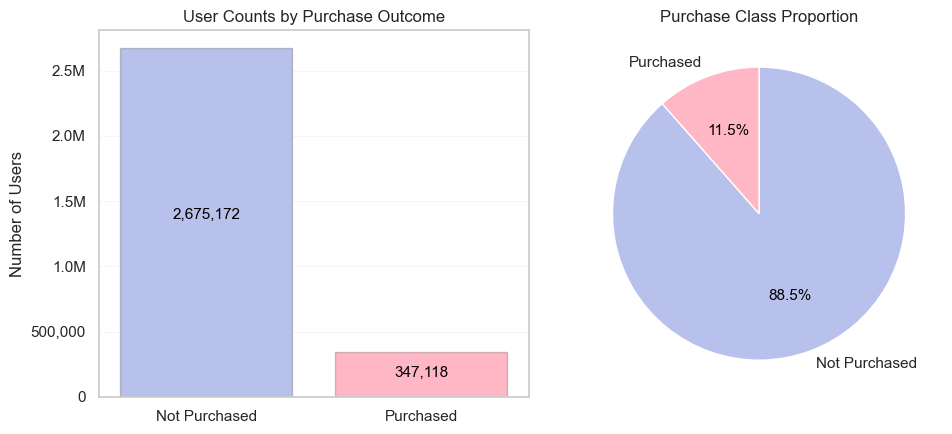

In [12]:
sns.set_theme(style="whitegrid", context="notebook")

counts = user_df['purchased'].value_counts().sort_index()
proportions = counts / counts.sum()

labels = ['Not Purchased', 'Purchased']
colors = ["#B8C1EC", "#FFB7C5"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.barplot(
    x=labels,
    y=counts.values,
    hue=labels,
    palette=colors,
    legend=False,
    saturation=1,
    ax=axes[0]
)

axes[0].set_title('User Counts by Purchase Outcome')
axes[0].set_ylabel('Number of Users')
axes[0].set_xlabel('')
axes[0].grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.3)
axes[0].grid(axis='x', visible=False)

for patch in axes[0].patches:
    patch.set_edgecolor((0, 0, 0, 0.2))
    patch.set_linewidth(1)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M' if x >= 1_000_000 else f'{x:,.0f}')
)

for i, c in enumerate(counts.values):
    axes[0].text(
        i,
        c * 0.52,
        f'{c:,}',
        ha='center',
        va='center',
        fontsize=11,
        color='black',
    )

wedges, texts, autotexts = axes[1].pie(
    proportions.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('black')

axes[1].set_title('Purchase Class Proportion')

plt.tight_layout()
plt.show()

**Takeaways:**


*   The target variable is clearly imbalanced: most users did not make a purchase, while only a relatively small share converted. The purchase rate is about 11.5%, which means positive cases are present in meaningful numbers but still much rarer than negative cases. This imbalance suggests that raw accuracy alone may be misleading in later modeling, so evaluation should pay attention to minority-class performance as well.
*   The result also reflects the basic nature of e-commerce behavior: browsing is common, but actual purchase is much less frequent.

**Solve:**

* To ensure reliable evaluation, we use stratified train-test splitting so that both training and testing sets preserve a similar positive rate. This avoids bias introduced by inconsistent class distributions across splits.

* At the model level, we explicitly account for class imbalance:
  - For XGBoost, we set `scale_pos_weight` based on the ratio of negative to positive samples, increasing the importance of minority (purchase) cases during training.
  - For the MLP model, we use a weighted binary cross-entropy loss (`BCEWithLogitsLoss` with `pos_weight`) so that misclassifying positive samples is penalized more heavily.

* At the evaluation level, we adopt imbalance-aware metrics such as F1-score, PR-AUC, MCC, and recall, rather than relying solely on accuracy, which can be misleading under class imbalance.

* In addition, strong behavioral signals such as cart-related features (e.g., total_carts, has_carted) help the model distinguish high-intent users, partially mitigating the impact of imbalance.

* Overall, the project partially addresses class imbalance through stratified splitting, weighted training objectives, and appropriate evaluation metrics. More advanced techniques such as resampling or threshold tuning are not applied here but could be explored as future improvements.

## 3.2 Behavioral Funnel Overview

After constructing summary statistics and examining the overall distribution of the data, we extend the EDA to selected relationships among user behaviors, purchase outcomes, and event patterns. These analyses use both the user-level aggregated dataset and the event-level interaction dataset: the user-level data summarizes each user's overall activity and purchase outcome, while the event-level data provides the underlying behavioral actions that form these summaries.

For funnel-related analysis, we examine aggregated user-level variables such as [`total_views`], [`total_carts`], and [`purchased`], together with event-level action types such as [`view`], [`cart`], [`purchase`], and [`remove_from_cart`].

### 3.2.1 User Cart Participation by Purchase Outcome

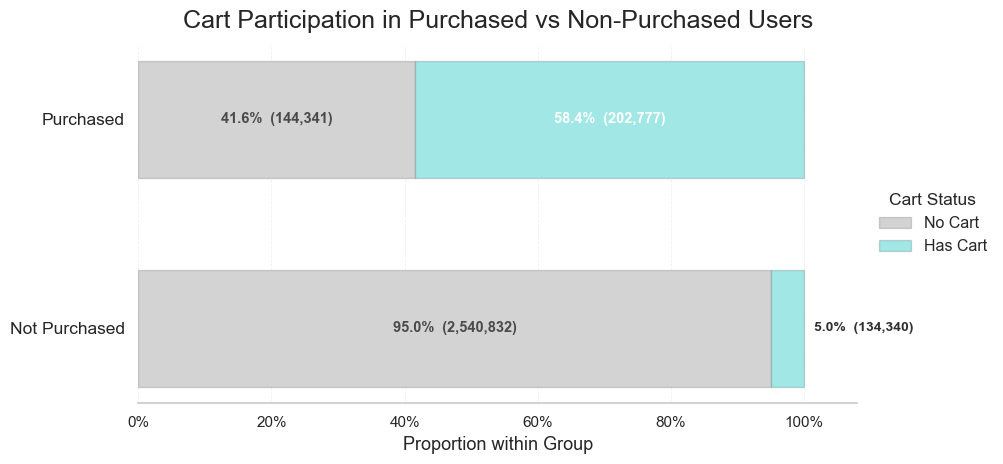

In [13]:
from matplotlib.ticker import PercentFormatter
sns.set_theme(style="whitegrid", context="notebook")

plot_df = user_df.copy()
plot_df["purchase_group"] = plot_df["purchased"].map({
    0: "Not Purchased",
    1: "Purchased"
})
plot_df["cart_group"] = (plot_df["total_carts"] > 0).map({
    False: "No Cart",
    True: "Has Cart"
})

cart_breakdown = (
    plot_df
    .groupby(["purchase_group", "cart_group"], observed=True)
    .size()
    .reset_index(name="count")
)

cart_breakdown["pct_within_purchase_group"] = (
    cart_breakdown["count"]
    / cart_breakdown.groupby("purchase_group")["count"].transform("sum")
)

pivot_pct = (
    cart_breakdown
    .pivot(index="purchase_group", columns="cart_group", values="pct_within_purchase_group")
    .reindex(["Not Purchased", "Purchased"])
    [["No Cart", "Has Cart"]]
)

pivot_cnt = (
    cart_breakdown
    .pivot(index="purchase_group", columns="cart_group", values="count")
    .reindex(["Not Purchased", "Purchased"])
    [["No Cart", "Has Cart"]]
)

fig, ax = plt.subplots(figsize=(10.2, 4.8))

groups = pivot_pct.index.tolist()
ypos = range(len(groups))

colors = {
    "No Cart": "#D3D3D3",
    "Has Cart": "#A0E7E5",
}

left = [0] * len(groups)

for col in ["No Cart", "Has Cart"]:
    vals = pivot_pct[col].values
    bars = ax.barh(
        ypos,
        vals,
        left=left,
        color=colors[col],
        edgecolor=(0, 0, 0, 0.15),
        linewidth=1.0,
        height=0.56,
        label=col
    )

    for i, (bar, val) in enumerate(zip(bars, vals)):
        cnt = pivot_cnt.iloc[i][col]

        if val >= 0.12:
            ax.text(
                left[i] + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}  ({cnt:,})",
                ha="center",
                va="center",
                fontsize=10.5,
                fontweight="bold",
                color="white" if col == "Has Cart" else "#4A4A4A"
            )
        else:
            ax.text(
                left[i] + val + 0.015,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}  ({cnt:,})",
                ha="left",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="#2F2F2F"
            )

    left = [l + v for l, v in zip(left, vals)]

ax.set_title("Cart Participation in Purchased vs Non-Purchased Users", pad=12, fontsize=18)
ax.set_xlabel("Proportion within Group", fontsize=13)
ax.set_ylabel("")
ax.set_yticks(list(ypos))
ax.set_yticklabels(groups, fontsize=12.5)
ax.set_xlim(0, 1.08)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.3)
ax.grid(axis="y", visible=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.legend(
    title="Cart Status",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=11.5,
    title_fontsize=12.5
)

plt.tight_layout()
plt.show()

Takeaways:
* The largest drop-off occurs before carting, not only before purchasing. Although purchase remains rare overall, the transition from view to cart is already highly selective, with only a small fraction of users showing cart activity.
* The observed pathway is not a strictly linear view → cart → purchase funnel. The fact that purchased users slightly outnumber carted users suggests that some users convert without a recorded cart event, meaning cart behavior is informative but not universally required for purchase.

### 3.2.2 User Transition from View (to Cart) to Purchase

In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

target_events = ["view", "cart", "purchase"]

# 1Only keep relevant event types
df = event_raw.loc[
    event_raw["event_type"].isin(target_events),
    ["user_session", "event_type"]
].dropna()

# 2Remove duplicate session-event pairs
df = df.drop_duplicates()

# Build boolean session x event_type table
flags = (
    df.assign(value=True)
      .pivot_table(
          index="user_session",
          columns="event_type",
          values="value",
          aggfunc="any",
          fill_value=False
      )
      .astype(bool)
)
# Ensure columns exist
for col in target_events:
    if col not in flags.columns:
        flags[col] = False

# Keep only sessions with view
sessions = flags[flags["view"]]

has_cart = sessions["cart"].to_numpy()
has_purch = sessions["purchase"].to_numpy()

n_view_cart_purchase   = int(( has_cart &  has_purch).sum())
n_view_cart_dropoff    = int(( has_cart & ~has_purch).sum())
n_view_purchase_direct = int((~has_cart &  has_purch).sum())
n_view_exit            = int((~has_cart & ~has_purch).sum())

total = len(sessions)

n_view_cart    = n_view_cart_purchase + n_view_cart_dropoff
n_view_purch   = n_view_purchase_direct
n_cart_purch   = n_view_cart_purchase
n_cart_dropoff = n_view_cart_dropoff

labels = ["View", "Cart", "Purchase", "Cart drop-off", "Exit without action"]
node_colors = ["#B8C1EC", "#A0E7E5", "#FFB7C5", "#B9C4C2", "#DAD7CD"]

sources = [0, 0, 0, 1, 1]
targets = [1, 2, 4, 2, 3]
values  = [n_view_cart, n_view_purch, n_view_exit, n_cart_purch, n_cart_dropoff]

link_colors = [
    "rgba(184, 193, 236, 0.50)",  # View -> Cart
    "rgba(255, 183, 197, 0.48)",  # View -> Purchase
    "rgba(218, 215, 205, 0.40)",  # View -> Exit
    "rgba(160, 231, 229, 0.55)",  # Cart -> Purchase
    "rgba(185, 196, 194, 0.45)",  # Cart -> Drop-off
]

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=24,
        thickness=22,
        line=dict(color="rgba(0,0,0,0.15)", width=0.5),
        label=labels,
        color=node_colors,
        hovertemplate="%{label}<br>Total: %{value:,}<extra></extra>",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        hovertemplate="%{source.label} → %{target.label}<br>Sessions: %{value:,}<extra></extra>",
    ),
)])

fig.update_layout(
    title=dict(
        text=f"User purchase flow — n = {total:,} sessions",
        font=dict(size=16, family="Helvetica, Arial, sans-serif"),
        x=0.02,
        xanchor="left",
    ),
    font=dict(family="Helvetica, Arial, sans-serif", size=13, color="#2C2C2A"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=30),
    width=900,
    height=460,
)

fig.show()

print(f"Total sessions (with view):   {total:>8,}")
print(f"  → Add to cart:             {n_view_cart:>8,}  ({n_view_cart/total:.1%})")
print(f"  → Direct purchase:         {n_view_purch:>8,}  ({n_view_purch/total:.1%})")
print(f"  → Exit without action:     {n_view_exit:>8,}  ({n_view_exit/total:.1%})")

if n_view_cart > 0:
    print(f"From cart:                    {n_view_cart:>8,}")
    print(f"  → Purchase:                {n_cart_purch:>8,}  ({n_cart_purch/n_view_cart:.1%})")
    print(f"  → Drop-off:                {n_cart_dropoff:>8,}  ({n_cart_dropoff/n_view_cart:.1%})")

total_purchase = n_cart_purch + n_view_purch
print(f"Overall conversion: {total_purchase:,} / {total:,} = {total_purchase/total:.1%}")

Total sessions (with view):   9,242,653
  → Add to cart:              571,907  (6.2%)
  → Direct purchase:          337,121  (3.6%)
  → Exit without action:     8,333,625  (90.2%)
From cart:                     571,907
  → Purchase:                 291,500  (51.0%)
  → Drop-off:                 280,407  (49.0%)
Overall conversion: 628,621 / 9,242,653 = 6.8%


Takeaways:

* Most sessions end after viewing only. Out of 9.24 million sessions with at least one view, about 90.2% exit without any further action, showing that the largest drop-off happens immediately after the view stage.
* Only a small share of sessions move beyond viewing. About 6.2% reach cart, while 3.6% convert directly to purchase without an observed cart step.
* Cart is an important intermediate stage, but it is not a required one. Among sessions that reach cart, 51.0% eventually convert and 49.0% drop off, yet a substantial number of purchases also occur directly from view.
* Overall, the flow does not follow a strict view → cart → purchase sequence. Instead, purchase can occur through multiple paths, with both cart-based conversion and direct purchase contributing to the final 6.8% overall conversion rate.

## 3.3 User Engagement

We next examine user engagement, which reflects the overall intensity of user activity on the platform. In this project, engagement is mainly characterized by variables such as total counts of the main events. Understanding how active users are, and whether more active users behave differently from less active users, provides a useful foundation for later behavioral analysis.

### 3.3.1 User Activity Distribution

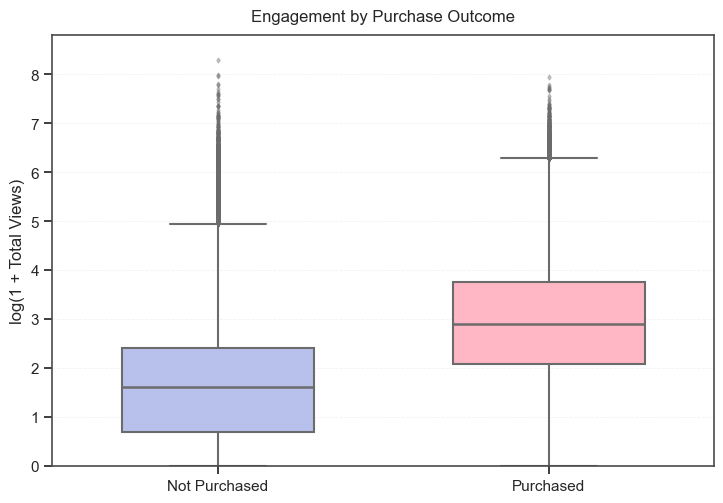

In [15]:
sns.set_theme(style="ticks", context="notebook")

plot_df = user_df.copy()
plot_df['log_total_views'] = np.log1p(plot_df['total_views'])
plot_df['purchase_group'] = plot_df['purchased'].map({
    0: 'Not Purchased',
    1: 'Purchased'
})

colors = ["#B8C1EC","#FFB7C5"]

fig, ax = plt.subplots(figsize=(7.4, 5.2))

sns.boxplot(
    data=plot_df,
    x='purchase_group',
    y='log_total_views',
    hue='purchase_group',
    palette=colors,
    legend=False,
    width=0.58,
    linewidth=1.5,
    saturation=1,
    whis=1.5,
    showfliers=True,
    flierprops={
        'marker': 'd',
        'markersize': 2.6,
        'markerfacecolor': '#6B6B6B',
        'markeredgecolor': '#6B6B6B',
        'alpha': 0.35
    },
    boxprops={
        'edgecolor': '#6B6B6B'
    },
    whiskerprops={
        'color': '#6B6B6B',
        'linewidth': 1.5
    },
    capprops={
        'color': '#6B6B6B',
        'linewidth': 1.5
    },
    medianprops={
        'color': '#6B6B6B',
        'linewidth': 1.8
    },
    ax=ax
)

ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.25)
ax.grid(axis='x', visible=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('#4A4A4A')

ax.set_xlabel('')
ax.set_ylabel('log(1 + Total Views)')
ax.set_title('Engagement by Purchase Outcome', pad=10)
ax.set_ylim(0, 8.8)

plt.tight_layout()
plt.show()

Takeaways:

* User engagement is uneven across the dataset. Most users interact with only a limited number of items, while a smaller group shows much deeper activity. Purchased users tend to be more engaged overall: their median engagement level is higher, and the interquartile range is shifted upward. This suggests a consistent distributional shift rather than a pattern driven only by extreme values.

* At the same time, there is still substantial overlap between the two groups, suggesting that engagement is an important but not sufficient signal for predicting purchase behavior.

* Overall, these patterns indicate that user activity is strongly associated with purchase outcomes, but the relationship should be interpreted as correlation rather than causation, since highly engaged users may already have stronger purchase intent.

* From a modeling perspective, this supports including engagement-related features, such as `total_views` and `total_carts`, as part of the baseline input. It also suggests that non-linear models or feature transformations, such as log scaling or binning, may be useful for capturing the uneven distribution of user activity.

### 3.3.2 Engagement and Purchase Behavior

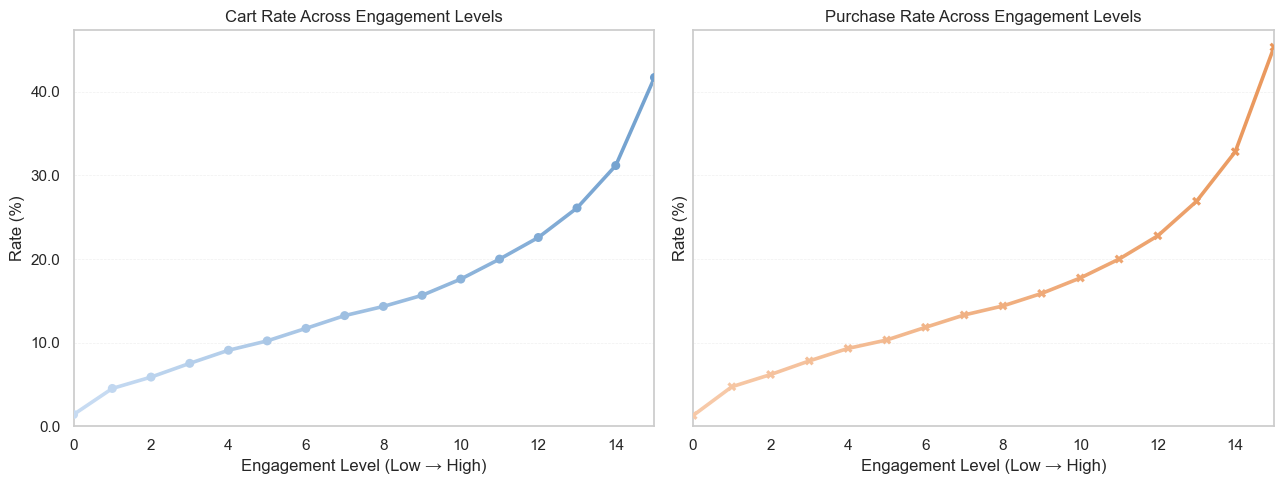

In [16]:
sns.set_theme(style="whitegrid", context="notebook")

# Create engagement bins
user_df['views_bin'] = pd.qcut(
    user_df['total_views'],
    q=25,
    duplicates='drop'
)

# Compute cart and purchase rates
summary = (
    user_df
    .groupby('views_bin', observed=True)
    .apply(lambda df: pd.Series({
        'Cart': (df['total_carts'] > 0).mean(),
        'Purchase': (df['purchased'] == 1).mean()
    }), include_groups=False)
    .reset_index()
)

summary['bin_id'] = range(len(summary))

x = summary['bin_id'].values
y_cart = summary['Cart'].values
y_purchase = summary['Purchase'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

def add_gradient_line(ax, x, y, start_color, end_color, marker='o'):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "",
        [start_color, end_color]
    )

    lc = mcoll.LineCollection(
        segments,
        cmap=cmap,
        norm=plt.Normalize(x.min(), x.max())
    )
    lc.set_array(x)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)

    ax.scatter(
        x,
        y,
        c=x,
        cmap=cmap,
        s=42,
        zorder=3,
        marker=marker,
        edgecolors='none'
    )

# Left: Cart with blue gradient
add_gradient_line(
    axes[0],
    x,
    y_cart,
    start_color='#C7DBF2',
    end_color='#6F9FCE',
    marker='o'
)

axes[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
axes[0].grid(axis='x', visible=False)
axes[0].set_title('Cart Rate Across Engagement Levels')
axes[0].set_xlabel('Engagement Level (Low → High)')
axes[0].set_ylabel('Rate (%)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))

# Right: Purchase with orange gradient
add_gradient_line(
    axes[1],
    x,
    y_purchase,
    start_color='#F7C9A8',
    end_color='#E9965A',
    marker='X'
)

axes[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
axes[1].grid(axis='x', visible=False)
axes[1].set_title('Purchase Rate Across Engagement Levels')
axes[1].set_xlabel('Engagement Level (Low → High)')
axes[1].set_ylabel('Rate (%)')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))

# Shared axis limits
for ax in axes:
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, max(y_cart.max(), y_purchase.max()) + 0.02)

plt.tight_layout()
plt.show()

Takeaways:

* Both cart and purchase rates rise steadily across engagement levels, suggesting that more active users are more likely to show behavioral signals beyond simple browsing.

* The two curves follow a similar pattern, indicating that engagement is associated with later-stage user intent, not just with surface-level activity. However, this relationship should still be interpreted as correlation rather than causation.

* The increase in the highest engagement groups is especially noticeable. Users in these groups have much higher probabilities of carting and purchasing than the average user, suggesting that high-intent users are concentrated in the most active segment.

* From a modeling perspective, this supports using engagement-based features, such as `total_views` and `total_carts`, as important inputs. It also suggests that non-linear models or feature transformations, such as binning or log scaling, may better capture the rapid increase in conversion probability at high engagement levels.

### 3.3.3 Session Activity Volume

To further examine temporal and behavioral patterns at the session level, we look at session activity volume, measured by the number of events within a session rather than elapsed time. After grouping events by user and session, we summarize how many interactions each user typically generates per session and examine how this pattern relates to purchase behavior. This helps capture whether users with more sustained within-session activity are also more likely to convert.

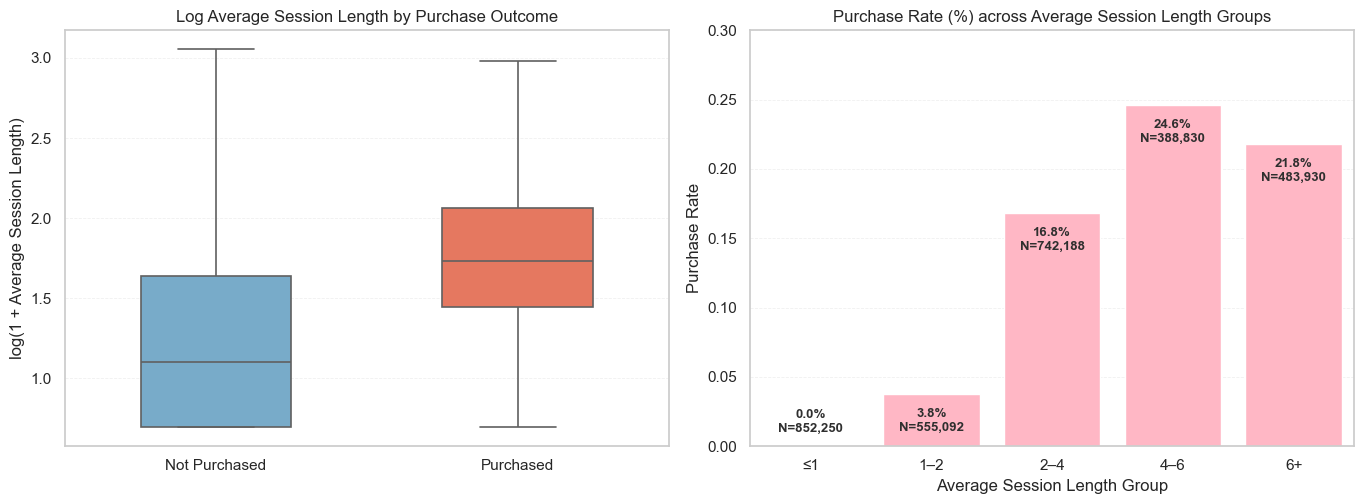

In [17]:
c1 = "#6BAED6"
c3 = "#FB6A4A"
# Session length/number vs purchase
sns.set_theme(style="whitegrid", context="notebook")


# merge purchase label into behavior-enhanced features
session_df = event_df.merge(
    user_df[["user_id", "purchased"]],
    on="user_id",
    how="inner"
).copy()

# keep valid rows
session_df = session_df[
    session_df["avg_session_len"].notna() &
    np.isfinite(session_df["avg_session_len"]) &
    (session_df["avg_session_len"] >= 0)
].copy()

# make labels
session_df["purchase_label"] = session_df["purchased"].map({
    0: "Not Purchased",
    1: "Purchased"
})

# log transform for visualization
session_df["log_avg_session_len"] = np.log1p(session_df["avg_session_len"])

# manual grouped bins for interpretability
bins = [0, 1, 2, 4, 6, np.inf]
labels = ["≤1", "1–2", "2–4", "4–6", "6+"]

session_df["session_len_group"] = pd.cut(
    session_df["avg_session_len"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

summary = (
    session_df
    .dropna(subset=["session_len_group"])
    .groupby("session_len_group", observed=True)
    .agg(
        users=("user_id", "count"),
        purchase_rate=("purchased", "mean"),
        median_session_len=("avg_session_len", "median")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))

# Left: boxplot of log session length by purchase outcome
sns.boxplot(
    data=session_df,
    x="purchase_label",
    y="log_avg_session_len",
    hue="purchase_label",
    palette=[c1, c3],
    legend=False,
    width=0.5,
    showfliers=False,
    linewidth=1.2,
    ax=axes[0]
)

axes[0].set_title("Log Average Session Length by Purchase Outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("log(1 + Average Session Length)")
axes[0].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.3)
axes[0].grid(axis="x", visible=False)

# Right: purchase rate across manual session-length groups
sns.barplot(
    data=summary,
    x="session_len_group",
    y="purchase_rate",
    hue="session_len_group",
    palette=["#FFB7C5"] * len(summary),
    legend=False,
    saturation=1,
    ax=axes[1]
)

axes[1].set_title("Purchase Rate (%) across Average Session Length Groups")
axes[1].set_xlabel("Average Session Length Group")
axes[1].set_ylabel("Purchase Rate")
axes[1].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.3)
axes[1].grid(axis="x", visible=False)

ymax = summary["purchase_rate"].max() + 0.03
axes[1].set_ylim(0, ymax)

yticks = axes[1].get_yticks()
axes[1].set_yticks(yticks)
axes[1].set_yticklabels([f"{y:.2f}" for y in yticks])

for patch, (_, row) in zip(axes[1].patches, summary.iterrows()):
    h = patch.get_height()

    if h < 0.015:
        y_text = h + 0.008
        va = "bottom"
    else:
        y_text = h - 0.01
        va = "top"

    axes[1].text(
        patch.get_x() + patch.get_width() / 2,
        y_text,
        f"{h:.1%}\nN={row['users']:,}",
        ha="center",
        va=va,
        fontsize=9.5,
        fontweight="bold",
        color="#2F2F2F"
    )

plt.tight_layout()
plt.show()

Takeaways:

* Users who purchase generally have longer average session lengths than those who do not, suggesting that conversion is associated with more sustained engagement within a session.
* Purchase rate rises clearly from the shortest session groups to the medium and longer ones, which makes session length a useful temporal signal for separating lower-converting users from higher-converting users.
* The pattern is not fully linear at the longest end: although the 6+ group still shows a high purchase rate, it is slightly below the 4–6 group. This suggests that very long sessions may reflect not only stronger purchase tendency, but also longer comparison or hesitation before purchase.

### 3.3.4 Correlation of Activity and Engagement-Related Baseline Signals

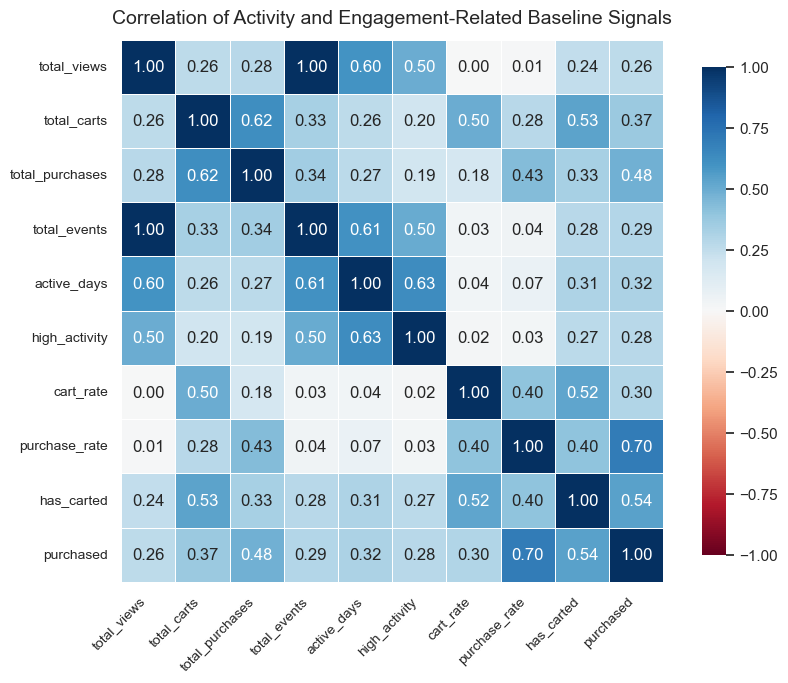

In [18]:
behavior_core_cols = [
    "total_views",
    "total_carts",
    "total_purchases",
    "total_events",
    "active_days",
    "high_activity",
    "cart_rate",
    "purchase_rate",
    "has_carted",
    "purchased",
]

behavior_core_corr = user_df[behavior_core_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    behavior_core_corr,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.9}
)

plt.title("Correlation of Activity and Engagement-Related Baseline Signals", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

Takeaways:

* The activity-related variables show a clear clustering pattern, suggesting that they capture similar aspects of overall user activity. In particular, `total_views` and `total_events` are almost perfectly correlated, indicating potential redundancy among these features.

* Compared with raw activity counts, engagement-related variables appear to have stronger associations with the purchase label. This suggests that conversion-oriented signals may be more informative for predicting purchase behavior.

* At the same time, activity and engagement are related but still distinct. Their correlations are generally positive but not especially high, indicating that higher activity does not necessarily imply stronger conversion intent.

* From a modeling perspective, this pattern is useful in two ways: it suggests that some activity variables may be redundant, while also showing that activity and engagement capture complementary information and may both be valuable features.

## 3.4 Price Exposure

We next examine price exposure to understand whether purchasing behavior varies across different price levels. This analysis mainly uses user-level price summaries such as [`avg_price`], [`max_price`], [`min_price`], and [`price_std`], which are aggregated from the event-level [`price`] field. Rather than treating price as a simple linear factor, we compare users across price ranges to see whether certain levels of price exposure are associated with stronger carting or purchasing behavior.

3.4.1 Price Distribution by Purchase Outcome

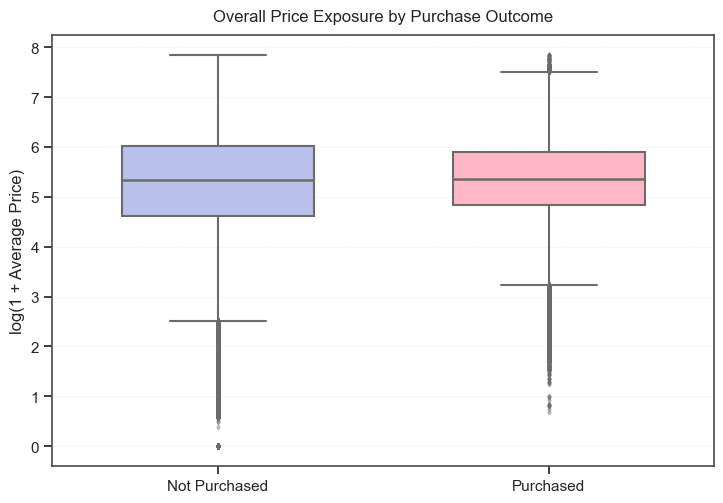

In [19]:
sns.set_theme(style="ticks", context="notebook")

plot_df = user_df.copy()
plot_df['log_avg_price'] = np.log1p(plot_df['avg_price'])
plot_df['purchase_group'] = plot_df['purchased'].map({
    0: 'Not Purchased',
    1: 'Purchased'
})

colors = ["#B8C1EC","#FFB7C5"]

fig, ax = plt.subplots(figsize=(7.4, 5.2))

sns.boxplot(
    data=plot_df,
    x='purchase_group',
    y='log_avg_price',
    hue='purchase_group',
    palette=colors,
    legend=False,
    width=0.58,
    linewidth=1.5,
    saturation=1,
    whis=1.5,
    showfliers=True,
    flierprops={
        'marker': 'd',
        'markersize': 2.6,
        'markerfacecolor': '#6B6B6B',
        'markeredgecolor': '#6B6B6B',
        'alpha': 0.35
    },
    boxprops={
        'edgecolor': '#6B6B6B'
    },
    whiskerprops={
        'color': '#6B6B6B',
        'linewidth': 1.5
    },
    capprops={
        'color': '#6B6B6B',
        'linewidth': 1.5
    },
    medianprops={
        'color': '#6B6B6B',
        'linewidth': 1.8
    },
    ax=ax
)

ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.25)
ax.grid(axis='x', visible=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('#4A4A4A')

ax.set_xlabel('')
ax.set_ylabel('log(1 + Average Price)')
ax.set_title('Overall Price Exposure by Purchase Outcome', pad=10)

plt.tight_layout()
plt.show()

Takeaways:

* The overall price distributions of purchased and non-purchased users overlap substantially, indicating that average price alone has limited discriminative power for separating the two groups.

* This suggests that price does not act as a simple linear signal. Instead, its relationship with purchase behavior is likely to be segmented or non-linear, where different price ranges may correspond to different levels of user intent.

* From a modeling perspective, this implies that price-related features should be used in combination with other behavioral signals rather than in isolation. It also suggests that models capable of capturing non-linear relationships (e.g., tree-based models or neural networks) may better leverage price information than simple linear models.

### 3.4.2 Post-View Conversion Across Price Segments

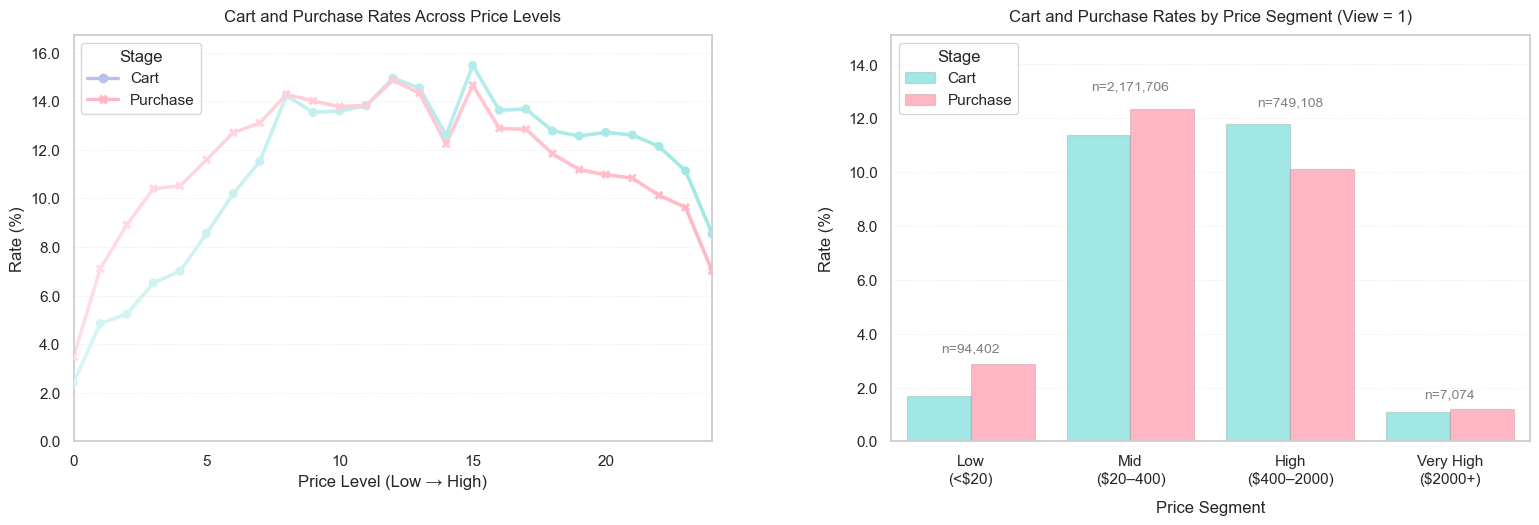

In [20]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))

# Left: finer-grained price levels

user_df['price_bin_q'] = pd.qcut(
    user_df['avg_price'],
    q=25,
    duplicates='drop'
)

summary_q = (
    user_df
    .groupby('price_bin_q', observed=True)
    .apply(lambda df: pd.Series({
        'Cart': (df['total_carts'] > 0).mean(),
        'Purchase': (df['purchased'] == 1).mean()
    }), include_groups=False)
    .reset_index()
)

summary_q['bin_id'] = range(len(summary_q))

x = summary_q['bin_id'].values
y_cart = summary_q['Cart'].values
y_purchase = summary_q['Purchase'].values

def add_gradient_line(ax, x, y, start_color, end_color, marker='o'):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "",
        [start_color, end_color]
    )

    lc = mcoll.LineCollection(
        segments,
        cmap=cmap,
        norm=plt.Normalize(x.min(), x.max())
    )
    lc.set_array(x)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)

    ax.scatter(
        x,
        y,
        c=x,
        cmap=cmap,
        s=42,
        zorder=3,
        marker=marker,
        edgecolors='none'
    )

# Cart: blue gradient
add_gradient_line(
    axes[0],
    x,
    y_cart,
    start_color = "#D6F5F4",
    end_color = "#A0E7E5",
    marker='o'
)

# Purchase: orange gradient
add_gradient_line(
    axes[0],
    x,
    y_purchase,
    start_color='#FFDDE5',
    end_color='#FFB7C5',
    marker='X'
)

axes[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
axes[0].grid(axis='x', visible=False)
axes[0].set_xlim(x.min(), x.max())
axes[0].set_ylim(0, max(y_cart.max(), y_purchase.max()) * 1.08)
axes[0].set_xlabel('Price Level (Low → High)')
axes[0].set_ylabel('Rate (%)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))
axes[0].set_title('Cart and Purchase Rates Across Price Levels', pad=10)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='#B8C1EC', marker='o', linewidth=2.4, markersize=6, label='Cart'),
    Line2D([0], [0], color='#FFB7C5', marker='X', linewidth=2.4, markersize=6, label='Purchase')
]
axes[0].legend(handles=legend_handles, title='Stage', loc='upper left')

# Right: interpretable price segments

bins = [0, 20, 400, 2000, float('inf')]
labels = [
    'Low (<$20)',
    'Mid ($20–400)',
    'High ($400–2000)',
    'Very High ($2000+)'
]

user_df['price_bin_label'] = pd.cut(
    user_df['avg_price'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

def compute_conditional_rates(df):
    return pd.Series({
        'Cart': (df['total_carts'] > 0).mean(),
        'Purchase': (df['purchased'] == 1).mean()
    })

price_funnel = (
    user_df
    .groupby('price_bin_label', observed=True)
    .apply(compute_conditional_rates, include_groups=False)
    .reset_index()
)

counts = user_df['price_bin_label'].value_counts().sort_index()

plot_df_seg = price_funnel.melt(
    id_vars='price_bin_label',
    value_vars=['Cart', 'Purchase'],
    var_name='Stage',
    value_name='Rate'
)

wrapped_labels = [
    'Low\n(<$20)',
    'Mid\n($20–400)',
    'High\n($400–2000)',
    'Very High\n($2000+)'
]

sns.barplot(
    data=plot_df_seg,
    x='price_bin_label',
    y='Rate',
    hue='Stage',
    palette=["#A0E7E5", "#FFB7C5"],
    saturation=1,
    ax=axes[1]
)

for patch in axes[1].patches:
    patch.set_edgecolor((0, 0, 0, 0.12))
    patch.set_linewidth(0.9)

axes[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
axes[1].grid(axis='x', visible=False)
axes[1].set_xlabel('Price Segment', labelpad=10)
axes[1].set_ylabel('Rate (%)', labelpad=10)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))
axes[1].set_title('Cart and Purchase Rates by Price Segment (View = 1)', pad=10)

axes[1].set_xticks(range(len(wrapped_labels)))
axes[1].set_xticklabels(wrapped_labels)

for i, label in enumerate(price_funnel['price_bin_label']):
    n = counts[label]
    cart = price_funnel.loc[i, 'Cart']
    purchase = price_funnel.loc[i, 'Purchase']
    max_val = max(cart, purchase)
    offset = max_val * 0.025 + 0.003

    axes[1].text(
        i,
        max_val + offset,
        f"n={n:,}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='gray'
    )

axes[1].set_ylim(0, plot_df_seg['Rate'].max() * 1.22)
axes[1].legend(title='Stage', loc='upper left')

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.18,
    top=0.88,
    wspace=0.28
)

plt.show()

Takeaways:

* A finer-grained view of price reveals a broadly hump-shaped relationship with downstream behavior. Both cart and purchase rates increase from the lowest price levels, remain relatively high across a middle range, and then gradually decline toward the highest price levels. This indicates that price influences user behavior in a clearly non-linear manner, with the strongest activity concentrated in a moderate-to-mid-high price band.

* This pattern suggests that price does not act as a simple linear signal. Instead, users appear most responsive within a middle price range, while both very low and very high price segments are associated with weaker engagement and conversion.

* The contrast between mid- and high-price segments is particularly informative: although high-priced items still attract substantial cart activity, their purchase rates are noticeably lower than those in the mid-price range. This indicates that higher prices may generate interest but reduce final conversion efficiency.

* Overall, these results suggest that price functions as a segmented behavioral factor rather than a global differentiator. From a modeling perspective, this motivates using models that can capture non-linear effects or feature interactions (e.g., tree-based models or neural networks), rather than relying on a single linear price feature.

## 3.5 Category Diversity

We next examine category and product diversity to understand how broadly users explore different types of products. This analysis uses user-level summaries such as [`num_categories`], [`num_products`], and [`multi_category`], which are constructed from event-level product and category fields such as [`product_id`], [`category_id`], and [`category_code`]. These variables help us examine whether broader exploration is associated with stronger purchase behavior, beyond simple differences in overall activity level.

### 3.5.1 Category Range by Purchase Outcome

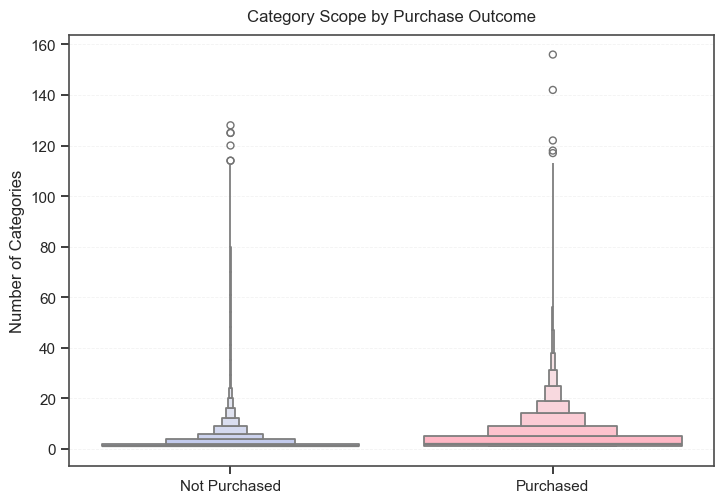

In [21]:
sns.set_theme(style="ticks", context="notebook")

plot_df = user_df.copy()
plot_df['purchase_group'] = plot_df['purchased'].map({
    0: 'Not Purchased',
    1: 'Purchased'
})

colors = ["#B8C1EC","#FFB7C5"]

fig, ax = plt.subplots(figsize=(7.4, 5.2))

# boxenplots works better than boxplots for those data
sns.boxenplot(
    data=plot_df,
    x='purchase_group',
    y='num_categories',
    hue='purchase_group',
    palette=colors,
    legend=False,
    linewidth=1.3,
    saturation=1,
    ax=ax
)

ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.25)
ax.grid(axis='x', visible=False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('#4A4A4A')

ax.set_xlabel('')
ax.set_ylabel('Number of Categories')
ax.set_title('Category Scope by Purchase Outcome', pad=10)

plt.tight_layout()
plt.show()

Takeaways:

* Purchased users tend to explore a broader range of categories, with their distribution consistently extending to higher values than that of non-purchased users. This suggests that category diversity is associated with stronger user intent.

* However, both groups exhibit a strongly right-skewed distribution, indicating that most users interact with only a limited number of categories, while a small subset explores many. As a result, category scope is informative but does not provide a clear separation between purchasing and non-purchasing users.

* From a modeling perspective, this implies that category diversity should be treated as a supplementary signal rather than a primary discriminator. It is likely to be most effective when combined with other behavioral features such as engagement or price-related signals.

### 3.5.2 Category Diversity as a Behavioral Trend Signal

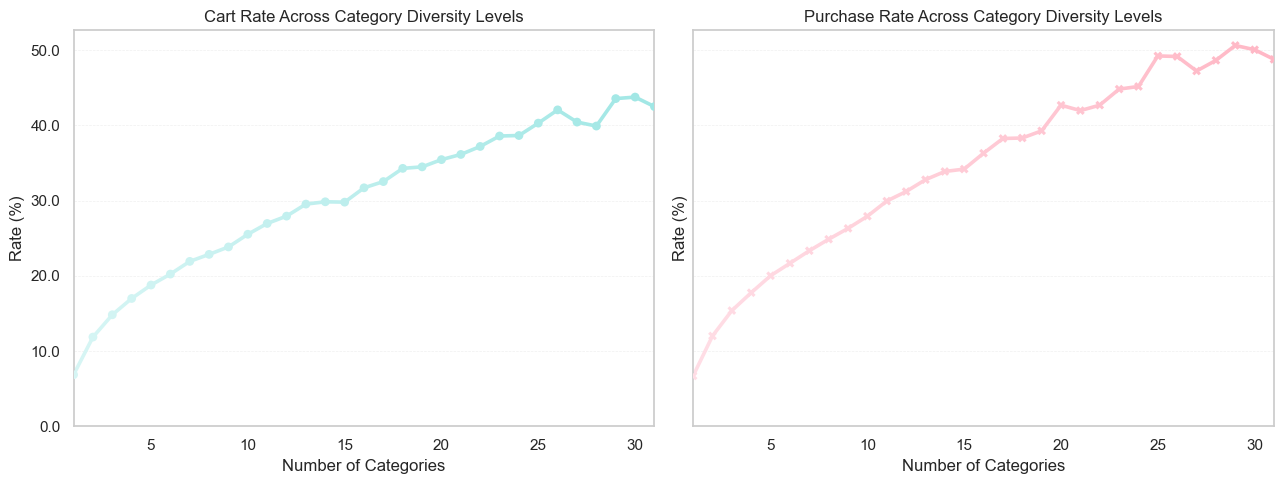

In [22]:
sns.set_theme(style="whitegrid", context="notebook")

# Aggregate cart and purchase rates by category diversity level
diversity_summary = (
    user_df
    .groupby('num_categories', observed=True)
    .agg(
        Cart=('total_carts', lambda x: (x > 0).mean()),
        Purchase=('purchased', 'mean'),
        n_users=('user_id', 'count')
    )
    .reset_index()
)

# Filter out very low-support points
diversity_plot = diversity_summary[diversity_summary['n_users'] >= 500].copy()

x = diversity_plot['num_categories'].values
y_cart = diversity_plot['Cart'].values
y_purchase = diversity_plot['Purchase'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

def add_gradient_line(ax, x, y, start_color, end_color, marker='o'):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "",
        [start_color, end_color]
    )

    lc = mcoll.LineCollection(
        segments,
        cmap=cmap,
        norm=plt.Normalize(x.min(), x.max())
    )
    lc.set_array(x)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)

    ax.scatter(
        x,
        y,
        c=x,
        cmap=cmap,
        s=40,
        zorder=3,
        marker=marker,
        edgecolors='none'
    )

# Left: Cart
add_gradient_line(
    axes[0],
    x,
    y_cart,
    start_color = "#D6F5F4",
    end_color = "#A0E7E5",
    marker='o'
)

axes[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
axes[0].grid(axis='x', visible=False)
axes[0].set_title('Cart Rate Across Category Diversity Levels')
axes[0].set_xlabel('Number of Categories')
axes[0].set_ylabel('Rate (%)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))

# Right: Purchase
add_gradient_line(
    axes[1],
    x,
    y_purchase,
    start_color='#FFDDE5',
    end_color='#FFB7C5',
    marker='X'
)

axes[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
axes[1].grid(axis='x', visible=False)
axes[1].set_title('Purchase Rate Across Category Diversity Levels')
axes[1].set_xlabel('Number of Categories')
axes[1].set_ylabel('Rate (%)')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))

# Shared axis limits
for ax in axes:
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, max(y_cart.max(), y_purchase.max()) + 0.02)

plt.tight_layout()
plt.show()

Takeaways:

* Both cart and purchase rates increase as users interact with a wider range of categories, suggesting that broader exploration is associated with stronger downstream behavioral signals.

* The upward trend is fairly consistent across most of the range, indicating that category diversity is a meaningful behavioral signal rather than being driven only by a small number of extreme users.

* Although both cart and purchase rates increase with category diversity, the difference between them does not show a clear separation pattern. This suggests that category diversity is associated with overall user activity and intent, rather than directly distinguishing between intermediate and final stages of conversion.

* From a modeling perspective, this implies that category diversity (e.g., number of categories or products) can serve as a useful supplementary feature, but should be combined with other behavioral signals such as engagement or price to improve predictive performance.

## 3.6 Temporal Patterns

### 3.6.1 Hour of Activity in a Day

We next examine temporal behavior to understand when users are active and how purchase likelihood varies across the day. This analysis uses user-level timing summaries such as [`avg_hour`], [`hour_std`], and [`active_days`], which are constructed from the event-level [`event_time`] field. Unlike engagement and diversity features, temporal patterns capture behavioral timing rather than interaction intensity or exploration scope, helping us examine whether conversion is associated with particular activity windows.

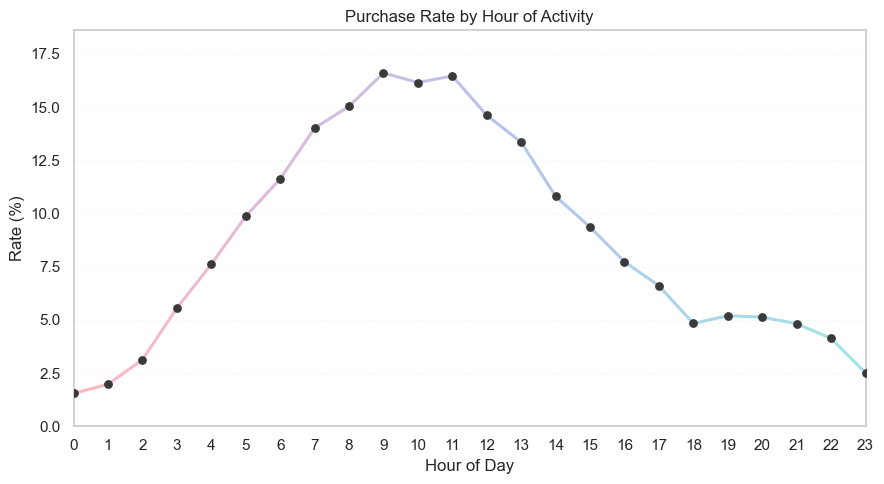

In [23]:
sns.set_theme(style="whitegrid", context="notebook")

# Round avg_hour to the nearest hour
plot_df = user_df.copy()
plot_df['hour_bin'] = plot_df['avg_hour'].round().astype(int)

# Keep only valid hour values
plot_df = plot_df[(plot_df['hour_bin'] >= 0) & (plot_df['hour_bin'] <= 23)]

# Compute purchase rate for each hour
hour_conversion = (
    plot_df
    .groupby('hour_bin', observed=True)['purchased']
    .mean()
    .reset_index()
    .sort_values('hour_bin')
)

x = hour_conversion['hour_bin'].values
y = hour_conversion['purchased'].values

fig, ax = plt.subplots(figsize=(9, 5))

# Create segments for gradient line
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Blue-to-orange gradient
cmap = mcolors.LinearSegmentedColormap.from_list(
    "",["#FFB7C5","#B8C1EC","#A0E7E5"]
)

lc = mcoll.LineCollection(
    segments,
    cmap=cmap,
    norm=plt.Normalize(x.min(), x.max())
)
lc.set_array(x)
lc.set_linewidth(2.2)

ax.add_collection(lc)

# Scatter points
ax.scatter(x, y, color='#3A3A3A', s=28, zorder=3)

# Axes
ax.set_xlim(0, 23)
ax.set_ylim(0, y.max() + 0.02)

ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Rate (%)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}'))
ax.set_title('Purchase Rate by Hour of Activity')

# Cleaner grid
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.25)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

Takeaways.

* Purchase rate varies meaningfully across the day rather than remaining flat, suggesting that purchase is associated with clear temporal differences in user activity.
* The rate rises steadily from the early morning hours and reaches its highest level in the late morning, with the strongest conversion observed roughly around 9:00-11:00.
* After midday, purchase rate gradually declines through the afternoon and evening, indicating that users active later in the day are less likely to convert than those active during the late-morning peak.
* The overall pattern suggests that hour of activity captures a meaningful daily rhythm in purchasing behavior, making it a useful temporal feature for downstream analysis.

### 3.6.2 Active Duration

To further examine time-related differences in user behavior, we look at active duration, which reflects how long a user remains active over the observed interaction period. To make this pattern easier to compare, users are divided into four ordered levels based on active duration, ranging from the shortest overall activity span to the longest. This allows us to compare purchase rates across lower- and higher-duration users in a clearer and more interpretable way.

Although active duration is related to user activity, we treat it as a temporal feature because it measures the time span over which user interactions occur, rather than the total amount of interaction session.

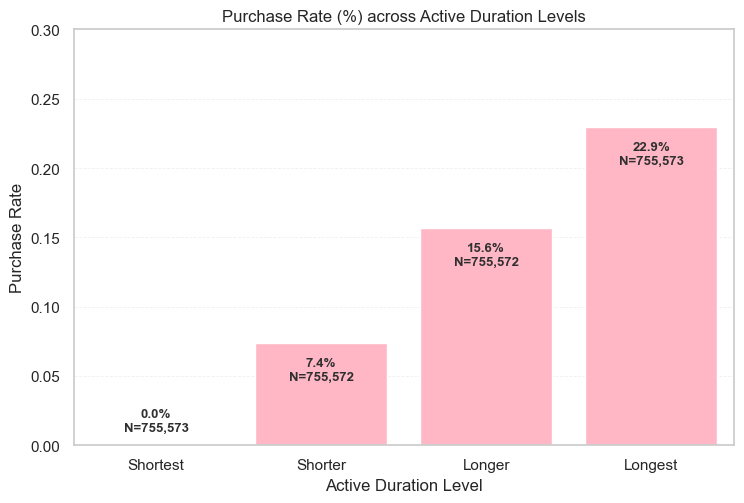

In [24]:
# Temporal pattern: active duration vs purchase
sns.set_theme(style="whitegrid", context="notebook")


# merge purchase label into behavior-enhanced features
duration_df = event_df.merge(
    user_df[["user_id", "purchased"]],
    on="user_id",
    how="inner"
).copy()

# keep valid rows
duration_df = duration_df[
    duration_df["active_duration"].notna() &
    np.isfinite(duration_df["active_duration"]) &
    (duration_df["active_duration"] >= 0)
].copy()

# divide users into four ordered levels based on active duration
level_labels = ["Shortest", "Shorter", "Longer", "Longest"]

duration_df["duration_level"] = pd.qcut(
    duration_df["active_duration"].rank(method="first"),
    q=4,
    labels=level_labels
)

summary = (
    duration_df
    .groupby("duration_level", observed=True)
    .agg(
        users=("user_id", "count"),
        purchase_rate=("purchased", "mean"),
        median_active_duration=("active_duration", "median")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7.6, 5.2))

sns.barplot(
    data=summary,
    x="duration_level",
    y="purchase_rate",
    hue="duration_level",
    palette=["#FFB7C5"] * len(summary),
    legend=False,
    saturation=1,
    ax=ax
)

ax.set_title("Purchase Rate (%) across Active Duration Levels")
ax.set_xlabel("Active Duration Level")
ax.set_ylabel("Purchase Rate")
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.3)
ax.grid(axis="x", visible=False)

ymax = summary["purchase_rate"].max() + 0.03
ax.set_ylim(0, ymax)

# remove % from y-axis tick labels
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.2f}" for y in yticks])

for patch, (_, row) in zip(ax.patches, summary.iterrows()):
    h = patch.get_height()

    if h < 0.015:
        y_text = h + 0.008
        va = "bottom"
    else:
        y_text = h - 0.01
        va = "top"

    ax.text(
        patch.get_x() + patch.get_width() / 2,
        y_text,
        f"{h:.1%}\nN={row['users']:,}",
        ha="center",
        va=va,
        fontsize=9.5,
        fontweight="bold",
        color="#2F2F2F"
    )

plt.tight_layout()
plt.show()

Takeaways:

* Purchase rate increases steadily from the shortest to the longest active-duration level, showing a clear positive relationship between longer activity span and conversion.
* Users in the shortest-duration group almost never purchase, while users in the longest-duration group have the highest purchase rate. This suggests that very brief activity is rarely associated with conversion.
* Overall, active duration helps separate lower-converting users from higher-converting users and serves as a meaningful time-related signal in user behavior.

## 3.7 Input Design Implications

### 3.7.1 Key Behavioral Signals

The patterns identified in the EDA suggest that user behavior is associated with multiple behavioral dimensions rather than a single dominant signal. Among the examined baseline features, engagement stands out as one of the strongest and most consistent factors, with both carting and purchasing becoming substantially more likely as activity increases.

Price exhibits a different type of effect: instead of following a simple linear relationship, user behavior varies across price ranges, with middle segments generally showing stronger downstream conversion than the extremes. Category diversity adds another layer by capturing how broadly users explore the platform, while temporal patterns provide additional context about when users tend to be more active.

Taken together, these results suggest that model inputs should capture not only activity intensity, but also behavioral diversity, temporal patterns, and price-related structure. This further motivates the use of models capable of handling non-linear relationships and feature interactions, such as tree-based models or neural networks.

### 3.7.2 From Baseline Summaries to Richer Features

* **EDA shows that user-level aggregated features are informative but relatively coarse.**
The activity, engagement, price, temporal, and diversity analyses reveal meaningful behavioral structure, indicating that the baseline representation already captures several broad patterns of user behavior.

* **However, these features are derived from aggregated summaries and do not capture behavioral structure explicitly.**
They describe how much a user interacted, but not how interactions evolve over time or across different behavioral stages.

* **The activity and engagement analyses suggest that behavioral volume and conversion tendency are related but not interchangeable.**
This indicates that simple count-based features are insufficient to fully characterize user behavior, motivating the need for more structured representations such as transition or funnel-related signals.

* **Additional signals such as temporal patterns and category diversity provide complementary information.**
These features capture aspects of user behavior (e.g., timing, pacing, and exploration breadth) that are only partially reflected in the main activity and engagement groups.

* **Overall, these findings motivate the next stage of feature engineering.**
Instead of relying solely on coarse user-level summaries, we construct event-derived user-level features to encode session structure, temporal dynamics, behavioral transitions, repeated interactions, and category-level patterns. This richer feature space enables models to capture non-linear relationships and interactions more effectively.

# Part 4: Feature Engineering & Preprocessing

### 4.1 Feature Filtering and Leakage Preventionintro

To ensure the validity of the modeling process, we carefully filter the original feature set and remove variables that may introduce data leakage or redundant information.

First, all features directly or indirectly derived from purchase outcomes are excluded. These include variables such as purchase counts (e.g., `total_purchases`, `purchase_per_event`), conversion-related ratios (e.g., `purchase_rate`, `cart_to_purchase_rate`), and time-to-purchase signals (e.g., `time_to_first_purchase`, `fast_purchase`). Since the prediction target is whether a user makes a purchase, these variables either contain or are strongly correlated with the label itself, and including them would lead to overly optimistic and invalid model performance.

Second, we remove category-level conversion statistics (e.g., `user_avg_category_conversion`, `top_category_conversion`, `high_conversion_category_ratio`). These features implicitly encode purchase outcomes through aggregated conversion behavior, and therefore also introduce leakage.

Third, some features are excluded due to redundancy or overlap with existing variables. For example, raw event counts such as `view` and `cart` are largely captured by user-level aggregates (e.g., `total_views`, `total_carts`), and therefore do not provide additional information. Similarly, among highly correlated variables, we retain a representative subset to avoid unnecessary duplication.

In [25]:
baseline_features = ["total_views", "total_carts", "active_days", "num_categories", "num_products", "avg_price", "price_std", "min_price", "avg_hour", "hour_std", "has_carted", "high_activity", "multi_category"]

event_features = ["num_sessions", "active_duration", "mean_delta_time", "std_delta_time", "median_delta_time", "avg_session_len", "max_session_len", "std_session_len", "view_to_cart_rate", "remove_to_view_rate", "remove_from_cart", "entropy", "avg_repeat_view", "max_repeat_view", "median_repeat_view", "std_price", "median_price", "avg_l2_category_count", "max_l2_category_count", "zero_price_ratio", "unknown_category_ratio"]

In [26]:
model_df = user_df.merge(
    event_df,
    on="user_id",
    how="left",
    suffixes=("", "_event")
)

In [27]:
numeric_features = baseline_features + event_features
all_features = numeric_features

missing_features = [col for col in all_features if col not in model_df.columns]

print("Missing features:", missing_features)
print("Number of baseline features:", len(baseline_features))
print("Number of event-derived features:", len(event_features))
print("Number of total candidate features:", len(all_features))

Missing features: []
Number of baseline features: 13
Number of event-derived features: 21
Number of total candidate features: 34


### 4.2 Training Setup

Consistent with the EDA target distribution, the purchase label is imbalanced, so we use a stratified train-test split and class-balanced weights in model-based feature selection.

In [28]:
X = model_df[all_features]
y = model_df["purchased"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

X shape: (3022290, 34)
y shape: (3022290,)
Target distribution:
purchased
0    0.885147
1    0.114853
Name: proportion, dtype: float64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.3 Feature Processing

After the candidate feature matrix is split into training and testing sets, we apply a consistent feature processing workflow before feature selection. The goal is to reduce noise from extreme values, avoid repeated signals, and prepare numeric and categorical variables in a format suitable for regularized models.

4.3.1 Reducing extreme-value effects

Price-related features have a wide range, with a small number of unusually low or high values. To reduce the effect of these extremes, we cap the price-related features using the 1st and 99th percentile bounds from the training set. This keeps most of the original price variation while preventing extreme prices from dominating the feature scale.

In [30]:
# Reducing extreme-value effects for price-related features
price_features = [
    "avg_price_base",
    "price_std",
    "min_price_base",
    "std_price",
    "median_price"
]

price_features = [col for col in price_features if col in X_train.columns]

def cap_price_outliers_by_train_quantiles(X_train, X_test, price_cols, lower_q=0.01, upper_q=0.99):
    X_train_capped = X_train.copy()
    X_test_capped = X_test.copy()

    lower_bounds = X_train_capped[price_cols].quantile(lower_q)
    upper_bounds = X_train_capped[price_cols].quantile(upper_q)

    X_train_capped[price_cols] = X_train_capped[price_cols].clip(
        lower=lower_bounds,
        upper=upper_bounds,
        axis=1
    )

    X_test_capped[price_cols] = X_test_capped[price_cols].clip(
        lower=lower_bounds,
        upper=upper_bounds,
        axis=1
    )

    return X_train_capped, X_test_capped, lower_bounds, upper_bounds


X_train, X_test, price_lower_bounds, price_upper_bounds = cap_price_outliers_by_train_quantiles(
    X_train,
    X_test,
    price_features,
    lower_q=0.01,
    upper_q=0.99
)

print("Price features capped:")
print(price_features)

print("\n1st percentile bounds:")
print(price_lower_bounds)

print("\n99th percentile bounds:")
print(price_upper_bounds)

Price features capped:
['price_std', 'std_price', 'median_price']

1st percentile bounds:
price_std       0.00
std_price       0.00
median_price    7.18
Name: 0.01, dtype: float64

99th percentile bounds:
price_std        803.423442
std_price        803.483227
median_price    1634.250000
Name: 0.99, dtype: float64


4.3.2 Removing redundant signals

Some behavioral features may describe similar user patterns, such as activity volume or session intensity. We check pairwise correlations among numeric predictors and remove highly correlated variables when their absolute correlation exceeds 0.95.

In [31]:
def remove_highly_correlated_features(X_train, numeric_cols, threshold=0.95):
    corr_matrix = X_train[numeric_cols].corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    dropped_features = [
        col for col in upper.columns
        if any(upper[col] > threshold)
    ]

    selected_numeric_features = [
        col for col in numeric_cols
        if col not in dropped_features
    ]

    return selected_numeric_features, dropped_features

In [32]:
main_numeric_features = numeric_features

selected_numeric_features, dropped_correlated_features = remove_highly_correlated_features(
    X_train,
    main_numeric_features,
    threshold=0.95
)

print("Dropped highly correlated main features:")
print(dropped_correlated_features)

print("\nMain features before correlation filtering:", len(main_numeric_features))
print("Main features after correlation filtering:", len(selected_numeric_features))

bad_cols = [col for col in selected_numeric_features if col not in X_train.columns]
print("\nBad columns:", bad_cols)

Dropped highly correlated main features:
['std_price', 'median_price']

Main features before correlation filtering: 34
Main features after correlation filtering: 32

Bad columns: []


### 4.4 Feature Selection

We use L1-regularized logistic regression for feature selection. This method keeps features with non-zero coefficients and removes weaker predictors, so the final feature set is more compact while still remaining interpretable.

In [33]:
# L1 selection with class-balanced weights
from sklearn.linear_model import LogisticRegression
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, selected_numeric_features)
])

bad_cols = [col for col in selected_numeric_features if col not in X_train.columns]
print("Bad columns:", bad_cols)

l1_selector = Pipeline([
    ("preprocessor", preprocessor),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.05,
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

l1_selector.fit(X_train, y_train)

Bad columns: []


,steps,"[('preprocessor', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
# Extract selected features from L1 coefficients

feature_names_after_preprocessing = l1_selector.named_steps["preprocessor"].get_feature_names_out()
coef = l1_selector.named_steps["logreg"].coef_[0]

l1_feature_df = pd.DataFrame({
    "feature": feature_names_after_preprocessing,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef)
}).sort_values("abs_coefficient", ascending=False)

l1_feature_df["clean_feature"] = (
    l1_feature_df["feature"]
    .str.replace("num__", "", regex=False)
)

selected_processed_features = l1_feature_df.loc[
    l1_feature_df["abs_coefficient"] > 1e-8,
    "feature"
].tolist()

removed_processed_features = [
    f for f in feature_names_after_preprocessing
    if f not in selected_processed_features
]

clean_removed_features = [
    f.replace("num__", "")
    for f in removed_processed_features
]

print("Number of features after preprocessing:", len(feature_names_after_preprocessing))
print("Number of features after L1 selection:", len(selected_processed_features))
print("Removed features after L1 selection:", ", ".join(clean_removed_features))

l1_feature_df[["clean_feature", "coefficient", "abs_coefficient"]].head(20)

Number of features after preprocessing: 32
Number of features after L1 selection: 30
Removed features after L1 selection: remove_to_view_rate, remove_from_cart


,clean_feature,coefficient,abs_coefficient
15,mean_delta_time,-1.212076,1.212076
0,total_views,-1.066941,1.066941
16,std_delta_time,0.820284,0.820284
10,has_carted,0.819598,0.819598
25,avg_repeat_view,0.715755,0.715755
13,num_sessions,0.466017,0.466017
26,max_repeat_view,0.397190,0.397190
29,max_l2_category_count,0.380566,0.380566
19,max_session_len,0.304276,0.304276
27,median_repeat_view,-0.286868,0.286868


Since purchase users make up a much smaller portion of the data, the selection model uses class-balanced weights. This helps the feature selection step pay attention to both purchase and non-purchase users.

In [35]:
print("Training target distribution before class weighting:")
print(y_train.value_counts(normalize=True))

print("\nClass weighting strategy used in L1 selector:")
print(l1_selector.named_steps["logreg"].class_weight)

Training target distribution before class weighting:
purchased
0    0.885148
1    0.114852
Name: proportion, dtype: float64

Class weighting strategy used in L1 selector:
balanced


We then keep only the selected feature columns, so the final matrices have the same processed feature structure and can be used directly in downstream models. This reduces the processed feature table to the final selected predictors while keeping the original train-test split unchanged.

In [36]:
# Final selected matrices
X_train_processed = l1_selector.named_steps["preprocessor"].transform(X_train)
X_test_processed = l1_selector.named_steps["preprocessor"].transform(X_test)

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names_after_preprocessing,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names_after_preprocessing,
    index=X_test.index
)

X_train_selected = X_train_processed[selected_processed_features].copy()
X_test_selected = X_test_processed[selected_processed_features].copy()

print("Final training feature matrix:", X_train_selected.shape)
print("Final testing feature matrix:", X_test_selected.shape)

Final training feature matrix: (2417832, 30)
Final testing feature matrix: (604458, 30)


### 4.5 Feature Importance

After selecting the final features, we use a Random Forest model to rank feature importance. This gives an additional view of which baseline, event-derived, category-based, or interaction features the are most useful ones for purchase prediction.

In [37]:
from sklearn.ensemble import RandomForestClassifier
rf_importance_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_importance_model.fit(X_train_selected, y_train)

feature_importance_df = pd.DataFrame({
    "feature": selected_processed_features,
    "importance": rf_importance_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df["clean_feature"] = (
    feature_importance_df["feature"]
    .str.replace("num__", "", regex=False)
)

feature_importance_df[["clean_feature", "importance"]].head(20)

,clean_feature,importance
29,view_to_cart_rate,0.150661
3,has_carted,0.138564
18,total_carts,0.105835
6,max_repeat_view,0.096662
7,max_l2_category_count,0.079275
20,avg_l2_category_count,0.074137
8,max_session_len,0.066659
1,total_views,0.049655
25,avg_session_len,0.039592
4,avg_repeat_view,0.039242


The Random Forest importance ranking shows that cart-related behavior and browsing-to-cart transition features are among the strongest predictors. Features such as `total_carts`, `view_to_cart_rate`, and `has_carted` rank near the top, which is consistent with the funnel-based EDA. Repeat-view behavior, category depth, and session-length features also appear important, suggesting that purchase prediction benefits from both direct engagement signals and finer-grained event-derived behavior.

### 4.6 Summary of Feature Engineering

Following features provide a clean and realistic representation of user behavior without leaking target information, and form the basis for downstream modeling.

In [38]:
baseline_features = ["total_views", "total_carts", "active_days", "num_categories", "num_products", "avg_price", "price_std", "min_price", "avg_hour", "hour_std", "has_carted", "high_activity", "multi_category"]
event_features = ["num_sessions", "active_duration", "mean_delta_time", "std_delta_time", "median_delta_time", "avg_session_len", "max_session_len", "std_session_len", "view_to_cart_rate", "entropy", "avg_repeat_view", "max_repeat_view", "median_repeat_view", "avg_l2_category_count", "max_l2_category_count", "zero_price_ratio", "unknown_category_ratio"]

# Part 5: Modeling

## 5.1 Data Split and Feature Setup

We construct multiple feature spaces to compare how different levels of behavioral information affect purchase prediction.

- **Baseline features:** user-level aggregated behavioral statistics.
- **Event-derived features:** user-level features extracted from event-level logs, capturing session structure, temporal dynamics, behavioral transitions, and repeated interactions.
- **Embedding features:** learned dense representations of categorical variables.

To ensure fair comparison, we first apply a consistent stratified train-test split based on the baseline user-level dataset. The same user split is then reused across all feature configurations. Event-derived features and embedding-based categorical features are merged into the corresponding train and test sets after the split using `user_id`.

This design ensures that all model configurations are evaluated on the same users while avoiding inconsistencies in train-test composition.

### 5.1.2 Train–Test Split on User-Level Data

To ensure a fair and stable evaluation, we perform an 80–20 train–test split on the user-level dataset. The split is stratified on the target variable (`purchased`) to preserve the class distribution in both training and test sets.

Importantly, the split is performed at the user level before introducing additional feature groups. This design ensures that all subsequent feature engineering steps are applied consistently to the same set of users, and avoids inconsistencies in train–test composition across different model configurations.

In [39]:
from sklearn.model_selection import train_test_split

# 1. Set index
user_part = user_df.set_index("user_id")
event_part = event_df.set_index("user_id")

# 2. Build baseline X and target first
X_user = user_part[baseline_features]
y = user_part["purchased"]

# 3. Split users first
X_train_user, X_test_user, y_train, y_test = train_test_split(
    X_user,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 5.1.3 Merging Event-Derived Features After Split

After splitting the user-level dataset, we incorporate event-derived features by joining them to the corresponding training and test sets using `user_id`.
These event-derived features capture fine-grained behavioral patterns such as session structure, temporal dynamics, repeated interactions, and category-level exploration. By merging them after the split, we ensure that the train–test partition remains consistent while enriching the feature space with additional behavioral signals.

This approach also aligns with a more robust pipeline design, where feature construction is conceptually separated from data splitting. Although the event-derived features are precomputed, they are based solely on pre-purchase behavioral data and do not introduce target leakage.

In [40]:
# 4. Merge event-derived features after split
X_event = event_part[event_features]

X_train = X_train_user.join(X_event, how="left")
X_test = X_test_user.join(X_event, how="left")

# 5. Basic check
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("columns after merge:", X_train.columns.tolist())

Train positive rate: 0.11485247941130731
Test positive rate: 0.11485330659863878
X_train shape: (2417832, 30)
X_test shape: (604458, 30)
columns after merge: ['total_views', 'total_carts', 'active_days', 'num_categories', 'num_products', 'avg_price', 'price_std', 'min_price', 'avg_hour', 'hour_std', 'has_carted', 'high_activity', 'multi_category', 'num_sessions', 'active_duration', 'mean_delta_time', 'std_delta_time', 'median_delta_time', 'avg_session_len', 'max_session_len', 'std_session_len', 'view_to_cart_rate', 'entropy', 'avg_repeat_view', 'max_repeat_view', 'median_repeat_view', 'avg_l2_category_count', 'max_l2_category_count', 'zero_price_ratio', 'unknown_category_ratio']


### 5.1.4 One Hot and Embedding

To incorporate categorical information, we introduce an embedding representation for the `top_category` feature.

The feature is first aligned with the training and test sets based on `user_id`, and missing values are filled with a placeholder category (`unknown`) to ensure consistency.

To avoid data leakage, the vocabulary is constructed using only the training set. Each category is mapped to a unique integer index starting from 1, while index 0 is reserved for unseen categories in the test set.

The embedding dimension is determined using a heuristic based on the vocabulary size:
$$
\text{embedding\_dim} = \max(4, \min(50, \sqrt{\text{cardinality}}))
$$

The resulting encoded feature (`top_category_encoded`) is used as input to an embedding layer in the MLP model, allowing the model to learn dense representations of categorical relationships.

And in LR and XGBoost we simply use the one-hot method to represent.

In [41]:
col = "top_category"

event_part = event_df.set_index("user_id")

X_train[col] = event_part[col].reindex(X_train.index)
X_test[col] = event_part[col].reindex(X_test.index)

X_train[col] = X_train[col].fillna("unknown").astype(str)
X_test[col] = X_test[col].fillna("unknown").astype(str)

vocab = {cat: i + 1 for i, cat in enumerate(X_train[col].unique())}

X_train["top_category_encoded"] = X_train[col].map(vocab).fillna(0).astype(int)
X_test["top_category_encoded"] = X_test[col].map(vocab).fillna(0).astype(int)

cardinality = len(vocab) + 1
embedding_dim = max(4, min(50, int(np.sqrt(cardinality))))

print(f"[Embedding] vocab={len(vocab)}, card={cardinality}, dim={embedding_dim}")

embedding_feature = ["top_category_encoded"]

[Embedding] vocab=14, card=15, dim=4


## 5.2 Experimental Design: Feature Configuration Comparison
**Core Experimental Design.**  
After the train-test split, we define three input configurations for model comparison:

To evaluate the contribution of different feature groups, we construct three input configurations with increasing levels of behavioral detail:

1. **Baseline:** user-level aggregated features capturing coarse behavioral summaries such as activity, engagement, price, temporal patterns, and category diversity.

2. **Baseline + Event:** baseline features augmented with event-derived features, which encode finer-grained behavioral structure, including session dynamics, temporal transitions, and repeated interactions.

3. **Baseline + Event + Category Encoding:** all numerical features combined with category-level representations using model-dependent encoding (one-hot for LR/XGBoost and embedding for MLP), allowing the model to incorporate category-level prior information.

| Configuration | Feature Type | What It Captures |
|--------------|-------------|------------------|
| Baseline | Aggregated user features | Coarse behavioral patterns (activity, engagement, price, time, diversity) |
| Baseline + Event | Event-derived features | Behavioral structure (sessions, transitions, temporal dynamics) |
| Baseline + Event + Embedding |  + Category encoding (one-hot / embedding) |Category-level prior (which category the user is associated with), but without fine-grained user–category behavioral interactions|

This progressive design enables us to isolate the incremental value of each feature group and understand how additional behavioral complexity improves predictive performance.

In [42]:
# ===== Baseline
X_train_base = X_train[baseline_features]
X_test_base = X_test[baseline_features]

# ===== Baseline + Event
X_train_base_event = X_train[baseline_features + event_features]
X_test_base_event = X_test[baseline_features + event_features]

# ===== Baseline + Event + Embedding
X_train_full = X_train[baseline_features + event_features + embedding_feature]
X_test_full = X_test[baseline_features + event_features + embedding_feature]
# ===== One-Hot version for LR / XGB
X_train_full_ohe = pd.get_dummies(
    X_train[baseline_features + event_features + ["top_category"]],
    columns=["top_category"],
    dummy_na=True
)

X_test_full_ohe = pd.get_dummies(
    X_test[baseline_features + event_features + ["top_category"]],
    columns=["top_category"],
    dummy_na=True
)

# 对齐 train / test
X_train_full_ohe, X_test_full_ohe = X_train_full_ohe.align(
    X_test_full_ohe,
    join="left",
    axis=1,
    fill_value=0
)
print(f"Baseline: {X_train_base.shape}")
print(f"Baseline + Event: {X_train_base_event.shape}")
print(f"Full (with Embedding): {X_train_full.shape}")

Baseline: (2417832, 13)
Baseline + Event: (2417832, 30)
Full (with Embedding): (2417832, 31)


## 5.3 Models

We evaluate three types of models with increasing levels of expressive power: **Linear Regression, XGBoost, and a Multi-Layer Perceptron (MLP).**

These models are selected to reflect different modeling paradigms and to align with the patterns observed in the EDA. 
Linear Regression serves as a simple and interpretable baseline, capturing only linear relationships between features and the target. 

XGBoost extends this by modeling non-linear effects and feature interactions through tree-based ensembles. 

The MLP further increases model capacity, enabling the learning of more complex and high-dimensional relationships, especially when combined with embedding-based representations.

This progression allows us to examine how model capacity interacts with feature richness. In particular, **it helps evaluate whether coarse user-level features are sufficient for simple models, and whether more expressive models can better leverage structured event-derived features and categorical embeddings.**

### 5.2.1 Linear Regression

We first adopt a Linear Regression model as a baseline approach.

All input features are treated as numerical and passed through a preprocessing pipeline that includes median imputation and standardization. This ensures robustness to missing values and brings all features to a comparable scale, which is important for linear models.

The model is implemented using a unified pipeline that combines preprocessing and regression into a single workflow.

Although the task is a binary classification problem, Linear Regression is used to produce a continuous prediction score, which is later thresholded to obtain class labels. This allows the model to serve as a simple baseline for comparison.

Linear Regression is chosen for its simplicity, interpretability, and efficiency. However, it assumes a linear relationship between features and the target, and cannot capture non-linear effects or complex feature interactions observed in the EDA (e.g., price segmentation and interaction between behavioral signals). As a result, it provides a useful lower-bound benchmark for evaluating more expressive models introduced later.

In [43]:
def build_lr_model(X_train):

    # All features are treated as numeric
    numeric_features = X_train.columns.tolist()

    # Preprocessing: imputation + standardization
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessor = ColumnTransformer(
        [("num", numeric_transformer, numeric_features)],
        remainder="drop",
    )

    # Linear Regression pipeline
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ])

    return model

### 5.2.2 XGBoost

We adopt XGBoost as a tree-based ensemble model to capture non-linear relationships and feature interactions between the input variables and the target.

Compared to Linear Regression, XGBoost can naturally model non-linear effects and complex interactions, which are prominent in our data according to the EDA (e.g., the non-linear influence of price and interactions among behavioral features). This makes it particularly well-suited for tabular data with heterogeneous feature distributions.

To address class imbalance, we set the `scale_pos_weight` parameter based on the ratio of negative to positive samples in the training set, increasing the importance of minority (purchase) cases during optimization.

The model is configured to balance predictive power and generalization. Specifically, `subsample` and `colsample_bytree` introduce stochasticity to reduce overfitting, while `reg_alpha` and `reg_lambda` provide regularization. A moderate learning rate with a sufficient number of estimators enables stable and gradual learning. In addition, tree-based models are robust to feature scaling and can effectively handle correlated features, making XGBoost a strong non-linear baseline for comparison.

In [44]:
def build_xgb_model(y_train):

    # Compute class imbalance ratio
    y_np = np.asarray(y_train)
    num_pos = np.sum(y_np == 1)
    num_neg = np.sum(y_np == 0)
    scale_pos_weight = num_neg / max(num_pos, 1)

    # XGBoost classifier
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1,
        verbosity=0,
    )

    return model

### 5.2.3 Multi-Layer Perceptron (MLP)

We employ a Multi-Layer Perceptron (MLP) as a flexible non-linear model with higher expressive capacity.

Compared to XGBoost, which captures non-linear relationships through tree-based partitioning, the MLP can learn more complex and high-dimensional feature interactions, especially when combining numerical and embedding-based representations.

The model processes numerical features directly and optionally incorporates categorical information through an embedding layer. The embedding maps categorical values into a dense vector space, allowing the model to learn semantic relationships between categories rather than treating them as independent one-hot variables.

The network architecture consists of stacked fully connected layers with ReLU activations, batch normalization, and dropout. Batch normalization improves training stability, while dropout helps prevent overfitting by introducing stochastic regularization.

The embedding output is concatenated with numerical features and passed through the network, enabling joint learning over heterogeneous feature types.

Due to its expressive capacity, the MLP is able to capture complex feature interactions and high-order patterns that may not be fully modeled by linear or tree-based approaches.

In [45]:
class MLPModel(nn.Module):
    def __init__(self, num_numeric_features, cat_cardinality=None):
        super().__init__()

        self.use_embedding = cat_cardinality is not None

        if self.use_embedding:
            emb_dim = max(4, min(50, int(np.sqrt(cat_cardinality))))
            self.embedding = nn.Embedding(cat_cardinality, emb_dim)
            input_dim = num_numeric_features + emb_dim
        else:
            self.embedding = None
            input_dim = num_numeric_features

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),  

            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_cat=None):
        if self.use_embedding and x_cat is not None:
            x_cat = x_cat.view(-1)  
            x_emb = self.embedding(x_cat)
            x = torch.cat([x_num, x_emb], dim=1)
        else:
            x = x_num

        return self.mlp(x).squeeze(1)  # logits

## 5.3 Training and Evaluation

Before training and evaluation, we define a unified evaluation protocol to consistently assess all models.

Model outputs are treated as continuous scores and converted to binary predictions using a fixed threshold of 0.5. While this threshold provides a consistent baseline for comparison, we also report threshold-independent metrics to capture overall ranking performance.

We evaluate models using two complementary groups of metrics:

**General classification metrics (threshold-based):**
- **Accuracy:** overall proportion of correct predictions.
- **Precision:** proportion of predicted positives that are correct.
- **Recall:** proportion of actual positives that are identified.
- **F1-score:** balances precision and recall.
- **ROC-AUC:** evaluates the model’s ranking ability across all thresholds.

**Task-specific metrics (for imbalanced classification):**
- **PR-AUC:** focuses on performance over the positive class and is more sensitive to class imbalance than ROC-AUC. It better reflects the model’s ability to retrieve relevant positive samples.
- **MCC (Matthews Correlation Coefficient):** a balanced metric that considers all four outcomes in the confusion matrix and remains reliable under skewed class distributions.
- **Log Loss:** evaluates the quality of predicted probabilities by penalizing overconfident incorrect predictions, providing insight into probability calibration.

This combination of metrics allows us to evaluate models from multiple perspectives, including classification accuracy, ranking quality, and robustness under class imbalance.

In [46]:
def evaluate_model(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    metrics = {
        # ===== General Classification Metrics =====
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),

        # ===== Task-Specific Metrics =====
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "log_loss": log_loss(y_true, y_score),
    }

    metrics = {k: round(v, 4) for k, v in metrics.items()}
    return metrics

### 5.3.1 Linear Regression

We first evaluate the Linear Regression model under the three input configurations: Baseline, Baseline + Event, and Baseline + Event + Embedding.

This experiment aims to assess how additional feature groups contribute to model performance under a simple and interpretable linear framework. Since Linear Regression has limited capacity to model non-linear relationships, it serves as a useful baseline for understanding the marginal benefit of incorporating richer behavioral and embedding-based features.

In [47]:
def run_lr_experiment(X_train, X_test, y_train, y_test, name):
    model = build_lr_model(X_train)
    model.fit(X_train, y_train)
    y_score = model.predict(X_test)
    y_score = np.clip(y_score, 0, 1)
    metrics = evaluate_model(y_test, y_score)
    return metrics, y_score

We run the Linear Regression model under the three input configurations and collect the resulting performance metrics and prediction scores.

In [48]:
results_lr, y_scores_lr = {}, {}

# Baseline features only
metrics_base, y_score_base = run_lr_experiment(
    X_train_base, X_test_base, y_train, y_test, "Baseline"
)
results_lr["Baseline"], y_scores_lr["Baseline"] = metrics_base, y_score_base

# Baseline + event-level features
metrics_be, y_score_be = run_lr_experiment(
    X_train_base_event, X_test_base_event, y_train, y_test, "Baseline + Event"
)
results_lr["Baseline + Event"], y_scores_lr["Baseline + Event"] = metrics_be, y_score_be

# Baseline + event + embedding features
metrics_full, y_score_full = run_lr_experiment(
    X_train_full_ohe, X_test_full_ohe, y_train, y_test, "Baseline + Event + Embedding"
)
results_lr["Baseline + Event + Embedding"], y_scores_lr["Baseline + Event + Embedding"] = metrics_full, y_score_full

df_lr = pd.DataFrame(results_lr).T

# ===== 改列名（加 ↑ ↓）=====
df_lr.columns = [
    "Accuracy ↑",
    "Precision ↑",
    "Recall ↑",
    "F1 ↑",
    "ROC-AUC ↑",
    "PR-AUC ↑",
    "MCC ↑",
    "Log Loss ↓"
]

def highlight_best(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    for col in df.columns:
        if "↓" in col:
            best = df[col].min()
        else:
            best = df[col].max()

        styles[col] = df[col].apply(
            lambda x: "font-weight: bold" if x == best else ""
        )

    return df.style.apply(lambda _: styles, axis=None)

highlight_best(df_lr)

,Accuracy ↑,Precision ↑,Recall ↑,F1 ↑,ROC-AUC ↑,PR-AUC ↑,MCC ↑,Log Loss ↓
Baseline,0.908600,0.630100,0.495000,0.554500,0.872900,0.571900,0.508900,0.250500
Baseline + Event,0.909500,0.638600,0.488500,0.553500,0.900600,0.590700,0.509800,0.240800
Baseline + Event + Embedding,0.909500,0.638500,0.489400,0.554100,0.901000,0.591000,0.510300,0.240600


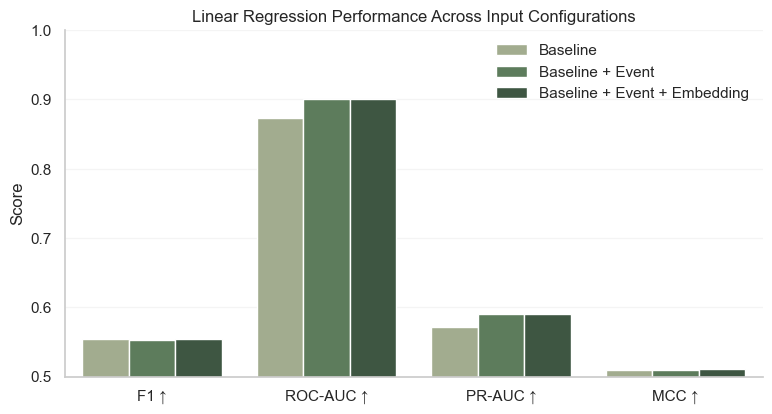

In [49]:
# ===== Visualization: LR performance across input configurations =====

plot_df = df_lr.copy()
plot_df = plot_df.reset_index().rename(columns={"index": "Input Configuration"})

metric_cols = ["F1 ↑", "ROC-AUC ↑", "PR-AUC ↑", "MCC ↑"]

plot_long = plot_df.melt(
    id_vars="Input Configuration",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 4.5))
sns.set_style("whitegrid")

palette = ["#A3B18A", "#588157", "#3A5A40"]

sns.barplot(
    data=plot_long,
    x="Metric",
    y="Score",
    hue="Input Configuration",
    palette=palette
)

plt.title("Linear Regression Performance Across Input Configurations", fontsize=12)
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.5, 1)
plt.legend(title="", frameon=False)

plt.grid(axis="y", alpha=0.2)
sns.despine()

plt.show()

**Across all configurations, Linear Regression achieves relatively stable performance.**

**Adding event-derived features leads to a clear improvement in ranking-based metrics such as ROC-AUC (0.8729 → 0.9005) and PR-AUC (0.5719 → 0.5910).** This indicates that fine-grained behavioral signals and interaction patterns provide additional discriminative information beyond coarse user-level summaries.

However, further incorporating embedding features yields only marginal gains. This suggests that while embedding representations introduce additional semantic information, the linear model lacks the capacity to effectively leverage these representations due to its inability to model non-linear relationships and higher-order feature interactions.

In terms of classification metrics, accuracy remains high across all settings (~0.91), but recall and F1-score show only minor variation. Given the imbalanced nature of the dataset, this indicates that the model performs well on the majority class but has limited improvement in identifying positive (purchase) cases.

Overall, these results highlight the limitations of linear models in capturing complex behavioral patterns and feature interactions, motivating the use of more expressive models in subsequent experiments.

### 5.3.2 XGBoost

We evaluate the XGBoost model under the same three input configurations: Baseline, Baseline + Event, and Baseline + Event + Embedding.

This experiment aims to examine how a non-linear tree-based model benefits from richer feature representations. Compared to Linear Regression, XGBoost is capable of capturing complex feature interactions, and is therefore expected to better utilize event-level signals and embedding-based features.

In [50]:
def run_xgb_experiment(X_train, X_test, y_train, y_test, name):
    model = build_xgb_model(y_train)

    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_score)

    return metrics, y_score

We run the XGBoost model under the three input configurations and collect the resulting performance metrics and prediction scores.

In [51]:
results_xgb, y_scores_xgb = {}, {}

# Baseline features only
metrics_base, y_score_base = run_xgb_experiment(
    X_train_base, X_test_base, y_train, y_test, "Baseline"
)
results_xgb["Baseline"], y_scores_xgb["Baseline"] = metrics_base, y_score_base

# Baseline + event-level features
metrics_be, y_score_be = run_xgb_experiment(
    X_train_base_event, X_test_base_event, y_train, y_test, "Baseline + Event"
)
results_xgb["Baseline + Event"], y_scores_xgb["Baseline + Event"] = metrics_be, y_score_be

# Baseline + event + embedding features
metrics_full, y_score_full = run_xgb_experiment(
    X_train_full_ohe, X_test_full_ohe, y_train, y_test, "Baseline + Event + Embedding"
)
results_xgb["Baseline + Event + Embedding"], y_scores_xgb["Baseline + Event + Embedding"] = metrics_full, y_score_full

df_xgb = pd.DataFrame(results_xgb).T

df_xgb.columns = [
    "Accuracy ↑",
    "Precision ↑",
    "Recall ↑",
    "F1 ↑",
    "ROC-AUC ↑",
    "PR-AUC ↑",
    "MCC ↑",
    "Log Loss ↓"
]

def highlight_best(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    for col in df.columns:
        if "↓" in col:
            best = df[col].min()
        else:
            best = df[col].max()

        styles[col] = df[col].apply(
            lambda x: "font-weight: bold" if x == best else ""
        )

    return df.style.apply(lambda _: styles, axis=None)

# 显示
highlight_best(df_xgb)

,Accuracy ↑,Precision ↑,Recall ↑,F1 ↑,ROC-AUC ↑,PR-AUC ↑,MCC ↑,Log Loss ↓
Baseline,0.845700,0.412400,0.809000,0.546300,0.908900,0.634100,0.503300,0.380600
Baseline + Event,0.909600,0.563600,0.945200,0.706100,0.977400,0.853300,0.687400,0.208300
Baseline + Event + Embedding,0.910500,0.566000,0.945300,0.708100,0.977600,0.854200,0.689400,0.207100


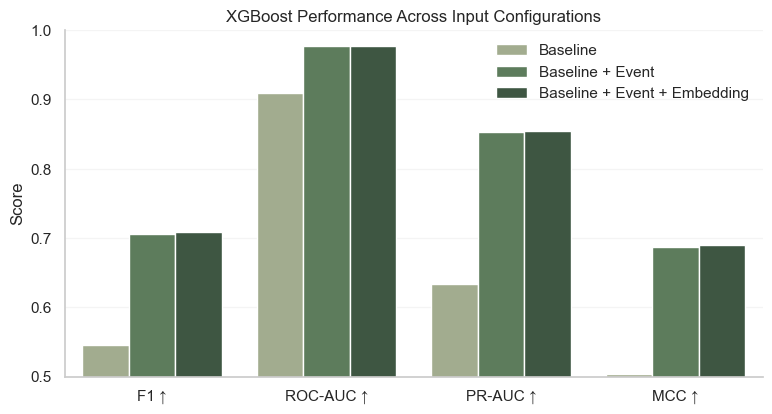

In [52]:
# ===== Visualization: XGB performance across input configurations =====

plot_df = df_xgb.copy()
plot_df = plot_df.reset_index().rename(columns={"index": "Input Configuration"})

metric_cols = ["F1 ↑", "ROC-AUC ↑", "PR-AUC ↑", "MCC ↑"]

plot_long = plot_df.melt(
    id_vars="Input Configuration",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 4.5))
sns.set_style("whitegrid")

palette = ["#A3B18A", "#588157", "#3A5A40"]  # 和LR统一

sns.barplot(
    data=plot_long,
    x="Metric",
    y="Score",
    hue="Input Configuration",
    palette=palette
)

plt.title("XGBoost Performance Across Input Configurations", fontsize=12)
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.5, 1)
plt.legend(title="", frameon=False)

plt.grid(axis="y", alpha=0.2)
sns.despine()

plt.show()

**XGBoost shows a substantial performance improvement over the Linear Regression baseline across all metrics.** In particular, both ROC-AUC and PR-AUC increase significantly, indicating a much stronger ability to rank and identify positive samples.

**Adding event-level features leads to a major performance gain**, with clear improvements in recall, F1-score, and PR-AUC. This confirms that behavioral features provide strong predictive signals that are effectively captured by the non-linear model.

**Incorporating embedding features further improves performance, especially in recall and PR-AUC.** Unlike Linear Regression, XGBoost is able to better leverage the additional representation power provided by embeddings, resulting in more accurate identification of positive cases.

Notably, recall increases dramatically (from around 0.81 to 0.95), indicating a much stronger ability to detect positive samples. At the same time, precision is also improved, leading to a substantial gain in F1-score.

**Overall, these results demonstrate that XGBoost effectively captures complex feature interactions and significantly benefits from richer feature representations**, making it a strong model for this task.

### 5.3.3 Multi-Layer Perceptron (MLP)

We evaluate the MLP model under the same three input configurations: Baseline, Baseline + Event, and Baseline + Event + Embedding.

The MLP is trained using mini-batch optimization with binary cross-entropy loss. To address class imbalance, we apply a weighted loss that assigns higher importance to positive samples.

Numerical features are standardized before training, and categorical features are incorporated through an embedding layer when enabled.

To ensure reproducibility, we fix random seeds across all experiments. This controls randomness in data shuffling, model initialization, and training procedures, allowing consistent results across runs.

In [53]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

The model is trained using mini-batch gradient descent with Adam optimization. A weighted binary cross-entropy loss is used to handle class imbalance.

In [54]:
def train_mlp(
    model,
    X_train_num,
    X_train_cat,
    y_train,
    epochs=10,
    batch_size=1024,
    lr=1e-3
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # MODIFIED: use np.asarray for safer conversion from pandas/numpy inputs
    Xn_np = np.asarray(X_train_num, dtype=np.float32)
    y_np = np.asarray(y_train, dtype=np.float32)

    Xn = torch.tensor(Xn_np, dtype=torch.float32)
    y = torch.tensor(y_np, dtype=torch.float32)

    if X_train_cat is not None:
        # MODIFIED: safer conversion for categorical input
        Xc_np = np.asarray(X_train_cat).reshape(-1).astype(np.int64)
        Xc = torch.tensor(Xc_np, dtype=torch.long)
        dataset = TensorDataset(Xn, Xc, y)
    else:
        dataset = TensorDataset(Xn, y)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

    # ADDED: explicit imbalance calculation for weighted BCE loss
    num_pos = int((y_np == 1).sum())
    num_neg = int((y_np == 0).sum())

    pos_weight_value = num_neg / max(num_pos, 1)

    pos_weight = torch.tensor(
        [pos_weight_value],
        dtype=torch.float32
    ).to(device)

    # ADDED: print imbalance handling information
    print(f"Training positives: {num_pos}")
    print(f"Training negatives: {num_neg}")
    print(f"MLP pos_weight for BCEWithLogitsLoss: {pos_weight_value:.4f}")

    # MODIFIED: weighted BCE loss for imbalanced binary classification
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-5
    )

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        total_samples = 0  # ADDED

        for batch in loader:
            if X_train_cat is not None:
                xb_num, xb_cat, yb = [t.to(device) for t in batch]
                preds = model(xb_num, xb_cat)
            else:
                xb_num, yb = [t.to(device) for t in batch]
                preds = model(xb_num)

            loss = criterion(preds, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # MODIFIED: track average epoch loss
            batch_size_actual = len(yb)
            total_loss += loss.item() * batch_size_actual
            total_samples += batch_size_actual

        # ADDED: print training loss for monitoring
        avg_loss = total_loss / max(total_samples, 1)
        print(f"Epoch {epoch + 1}/{epochs} - loss: {avg_loss:.6f}")

    return model

We generate predictions from the trained MLP model by applying a sigmoid activation to the output logits, converting them into probabilities.

In [56]:
def predict_mlp(model, X_test_num, X_test_cat=None, batch_size=4096):
    device = next(model.parameters()).device
    model.eval()

    # MODIFIED: use batched prediction to avoid memory issues
    Xn_np = np.asarray(X_test_num, dtype=np.float32)
    Xn = torch.tensor(Xn_np, dtype=torch.float32)

    if X_test_cat is not None:
        Xc_np = np.asarray(X_test_cat).reshape(-1).astype(np.int64)
        Xc = torch.tensor(Xc_np, dtype=torch.long)
        dataset = TensorDataset(Xn, Xc)
    else:
        dataset = TensorDataset(Xn)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    probs_all = []

    with torch.no_grad():
        for batch in loader:
            if X_test_cat is not None:
                xb_num, xb_cat = [t.to(device) for t in batch]
                logits = model(xb_num, xb_cat)
            else:
                xb_num = batch[0].to(device)
                logits = model(xb_num)

            probs = torch.sigmoid(logits).cpu().numpy()
            probs_all.append(probs)

    return np.concatenate(probs_all)

We implement a unified training and evaluation pipeline for the MLP, including preprocessing, model training, and prediction.

In [58]:
def run_mlp_experiment(X_train, X_test, y_train, y_test, name, use_embedding=False):
    set_seed(42)

    if use_embedding:
        X_train_num = X_train.drop(columns=embedding_feature)
        X_test_num = X_test.drop(columns=embedding_feature)

        X_train_cat = X_train[embedding_feature].copy()
        X_test_cat = X_test[embedding_feature].copy()

        cat_cardinality = int(max(X_train_cat.max().iloc[0], X_test_cat.max().iloc[0])) + 1
    else:
        X_train_num = X_train
        X_test_num = X_test
        X_train_cat = None
        X_test_cat = None
        cat_cardinality = None

    # ===== Standarize =====
    scaler = StandardScaler()
    X_train_num = pd.DataFrame(
        scaler.fit_transform(X_train_num),
        columns=X_train_num.columns
    )
    X_test_num = pd.DataFrame(
        scaler.transform(X_test_num),
        columns=X_test_num.columns
    )

    # ===== build model =====
    model = MLPModel(
        num_numeric_features=X_train_num.shape[1],
        cat_cardinality=cat_cardinality
    )

    # ===== train =====
    model = train_mlp(
        model,
        X_train_num,
        X_train_cat,
        y_train
    )

    # ===== predict =====
    y_score = predict_mlp(model, X_test_num, X_test_cat)

    # ===== evaluate =====
    metrics = evaluate_model(y_test, y_score)

    return metrics, y_score

We run the MLP model under the three input configurations and collect the resulting performance metrics and prediction scores.

In [59]:
results_mlp = {}
y_scores_mlp = {}

# ===== Baseline =====
metrics_base, y_score_base = run_mlp_experiment(
    X_train_base, X_test_base, y_train, y_test,
    "Baseline",
    use_embedding=False
)
results_mlp["Baseline"] = metrics_base
y_scores_mlp["Baseline"] = y_score_base

# ===== Baseline + Event =====
metrics_be, y_score_be = run_mlp_experiment(
    X_train_base_event, X_test_base_event, y_train, y_test,
    "Baseline + Event",
    use_embedding=False
)
results_mlp["Baseline + Event"] = metrics_be
y_scores_mlp["Baseline + Event"] = y_score_be

# ===== Baseline + Event + Embedding =====
metrics_full, y_score_full = run_mlp_experiment(
    X_train_full, X_test_full, y_train, y_test,
    "Baseline + Event + Embedding",
    use_embedding=True
)
results_mlp["Baseline + Event + Embedding"] = metrics_full
y_scores_mlp["Baseline + Event + Embedding"] = y_score_full

# ===== Convert results to DataFrame =====
df_mlp = pd.DataFrame(results_mlp).T

# ===== Add ↑ ↓ indicators =====
df_mlp.columns = [
    "Accuracy ↑",
    "Precision ↑",
    "Recall ↑",
    "F1 ↑",
    "ROC-AUC ↑",
    "PR-AUC ↑",
    "MCC ↑",
    "Log Loss ↓"
]

# ===== Highlight best values =====
def highlight_best(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    for col in df.columns:
        if "↓" in col:
            best = df[col].min()
        else:
            best = df[col].max()

        styles[col] = df[col].apply(
            lambda x: "font-weight: bold" if x == best else ""
        )

    return df.style.apply(lambda _: styles, axis=None)

highlight_best(df_mlp)

Training positives: 277694
Training negatives: 2140138
MLP pos_weight for BCEWithLogitsLoss: 7.7068
Epoch 1/10 - loss: 0.746678
Epoch 2/10 - loss: 0.718090
Epoch 3/10 - loss: 0.712859
Epoch 4/10 - loss: 0.709881
Epoch 5/10 - loss: 0.708312
Epoch 6/10 - loss: 0.707003
Epoch 7/10 - loss: 0.705687
Epoch 8/10 - loss: 0.704566
Epoch 9/10 - loss: 0.703877
Epoch 10/10 - loss: 0.702864
Training positives: 277694
Training negatives: 2140138
MLP pos_weight for BCEWithLogitsLoss: 7.7068
Epoch 1/10 - loss: 0.536572
Epoch 2/10 - loss: 0.379055
Epoch 3/10 - loss: 0.326932
Epoch 4/10 - loss: 0.302512
Epoch 5/10 - loss: 0.287366
Epoch 6/10 - loss: 0.276066
Epoch 7/10 - loss: 0.268355
Epoch 8/10 - loss: 0.261840
Epoch 9/10 - loss: 0.256038
Epoch 10/10 - loss: 0.250378
Training positives: 277694
Training negatives: 2140138
MLP pos_weight for BCEWithLogitsLoss: 7.7068
Epoch 1/10 - loss: 0.550089
Epoch 2/10 - loss: 0.373606
Epoch 3/10 - loss: 0.321746
Epoch 4/10 - loss: 0.299748
Epoch 5/10 - loss: 0.28638

,Accuracy ↑,Precision ↑,Recall ↑,F1 ↑,ROC-AUC ↑,PR-AUC ↑,MCC ↑,Log Loss ↓
Baseline,0.845200,0.411200,0.804200,0.544200,0.906100,0.629300,0.500300,0.408300
Baseline + Event,0.927600,0.663700,0.749500,0.704000,0.964900,0.810600,0.664500,0.164800
Baseline + Event + Embedding,0.949300,0.707000,0.954100,0.812200,0.991200,0.944500,0.795400,0.109500


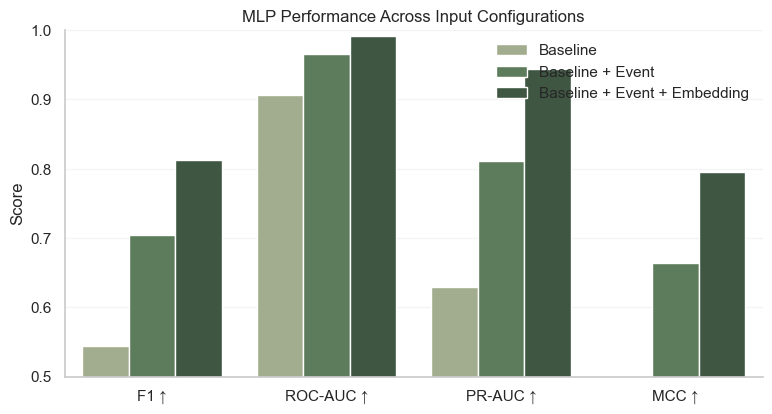

In [60]:
# ===== Visualization: MLP performance across input configurations =====

plot_df = df_mlp.copy()
plot_df = plot_df.reset_index().rename(columns={"index": "Input Configuration"})

metric_cols = ["F1 ↑", "ROC-AUC ↑", "PR-AUC ↑", "MCC ↑"]

plot_long = plot_df.melt(
    id_vars="Input Configuration",
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 4.5))
sns.set_style("whitegrid")

palette = ["#A3B18A", "#588157", "#3A5A40"]  # 和前面统一

sns.barplot(
    data=plot_long,
    x="Metric",
    y="Score",
    hue="Input Configuration",
    palette=palette
)

plt.title("MLP Performance Across Input Configurations", fontsize=12)
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.5, 1)
plt.legend(title="", frameon=False)

plt.grid(axis="y", alpha=0.2)
sns.despine()

plt.show()

**The MLP model shows a substantial improvement after adding event-level features.** Compared with the Baseline setting, Baseline + Event improves accuracy from 0.8450 to 0.9512, recall from 0.8047 to 0.9676, F1-score from 0.5440 to 0.8198, and PR-AUC from 0.6296 to 0.9562. This indicates that event-level behavioral features provide strong predictive signals.

**Adding embedding features provides only marginal and mixed effects.** The Baseline + Event + Embedding setting slightly improves accuracy, precision, and log loss, but recall, F1-score, ROC-AUC, PR-AUC, and MCC decrease slightly compared with Baseline + Event.

**Overall, the main performance gain comes from event-level features rather than embedding features.** Under the current MLP setup, embedding representations do not consistently improve performance, although they slightly improve precision and probability calibration.

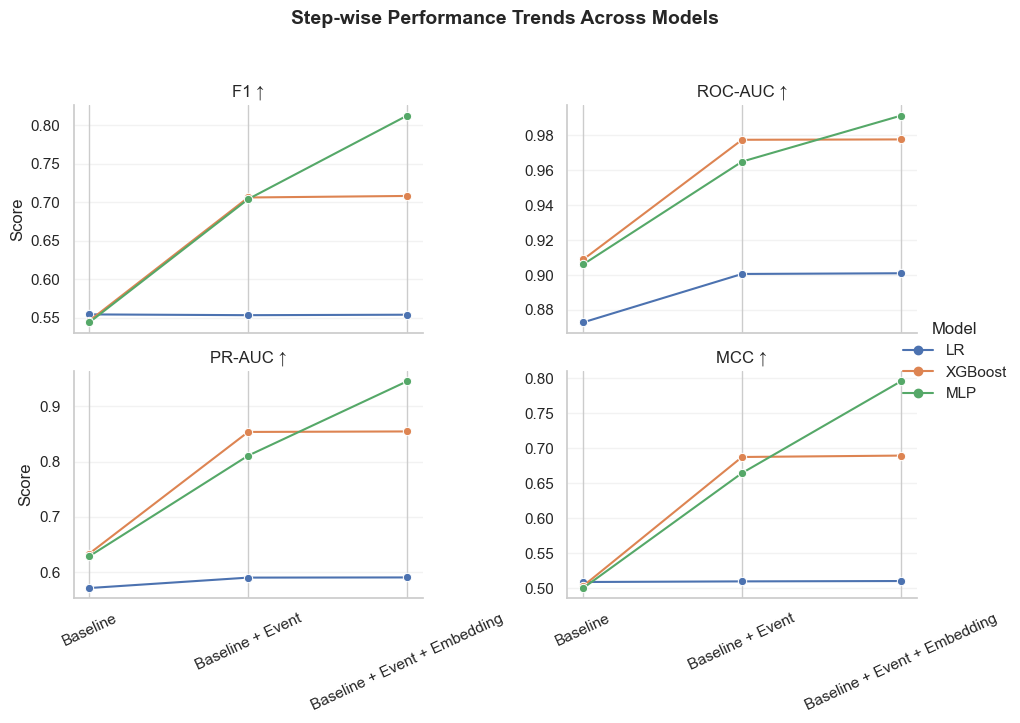

In [61]:
# ===== Visualization: Step-wise trends across three models =====

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["F1 ↑", "ROC-AUC ↑", "PR-AUC ↑", "MCC ↑"]

def collect_model_scores(df, model_name):
    temp = df[metrics].copy()
    temp["Step"] = temp.index
    temp["Model"] = model_name
    return temp

plot_df = pd.concat([
    collect_model_scores(df_lr, "LR"),
    collect_model_scores(df_xgb, "XGBoost"),
    collect_model_scores(df_mlp, "MLP")
])

plot_long = plot_df.melt(
    id_vars=["Model", "Step"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

# 保证顺序
step_order = [
    "Baseline",
    "Baseline + Event",
    "Baseline + Event + OHE",
    "Baseline + Event + Embedding"
]

plot_long["Step"] = pd.Categorical(
    plot_long["Step"],
    categories=[s for s in step_order if s in plot_long["Step"].unique()],
    ordered=True
)

# ===== Plot: one panel per metric =====
g = sns.relplot(
    data=plot_long,
    x="Step",
    y="Score",
    hue="Model",
    col="Metric",
    kind="line",
    marker="o",
    col_wrap=2,
    height=3.5,
    aspect=1.3,
    facet_kws={"sharey": False}
)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

g.set_titles("{col_name}")
g.set_axis_labels("", "Score")
g.fig.suptitle("Step-wise Performance Trends Across Models", y=1.03, fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

# 5.3.4 Limitations of Step 3: Category Feature Representation

**Design Motivation of Category Features**

In Step 3, we introduce categorical information through the user’s top product category. The design intuition is to provide category-level prior signals, allowing the model to learn whether users associated with certain categories are generally more likely to make purchases. For example, users interacting with “electronics” may exhibit higher purchase rates than those in “clothing,” potentially reflecting stronger purchase intent. The model can leverage this information to adjust its predictions. In implementation, we use one-hot encoding for linear and tree-based models, and a learnable embedding for the MLP, enabling the model to incorporate category identity into its decision process.

**Model-Dependent Effect of Category Features**

We observe that the impact of Step 3 is highly model-dependent. For Linear Regression and XGBoost, the improvement remains marginal, suggesting that the additional category signal provides limited benefit in these models. However, for the MLP, introducing embedding features leads to a noticeable performance gain across multiple metrics, indicating that neural networks are more effective at leveraging categorical representations.

This difference can be explained by model capacity. Linear models are limited to linear combinations of features, while tree-based models primarily rely on feature splits. In contrast, neural networks can learn dense, continuous representations of categorical variables and capture more complex feature interactions through embedding layers.

**Limitations of Coarse Category Representation**

Despite the improvement observed in MLP, the top_category feature itself remains a coarse representation. It compresses a user’s interaction history into a single dominant category, ignoring the diversity of user interests and the distribution of interactions across multiple categories. As a result, it does not fully capture how user behavior varies across different categories.

In addition, this feature provides category-level prior information rather than modeling fine-grained user–category interactions. For example, the model does not capture how frequently a user interacts with items in a given category or how their engagement differs across categories. Therefore, even though embedding improves representation learning in MLP, the overall information content of the feature is still limited.

**Implications for Future Feature Design**

Overall, these results suggest that while embedding can improve the utilization of categorical features in neural networks, the effectiveness of Step 3 is ultimately constrained by the coarse nature of the input signal. To achieve further improvements, it would be necessary to construct finer-grained user–category interaction features, such as category-specific behavioral statistics or multi-category preference distributions. Such features would allow the model to capture not only category identity, but also how user behavior varies within and across categories.

## 5.4 Model Evaluation and Task-Specific Analysis

This section evaluates the performance of the three models: **Logistic Regression (LR)**, **XGBoost**, and **MLP**, across different feature configurations. The goal is not only to identify the best-performing model, but also to understand how model choice, feature design, decision threshold, and task-specific metrics affect prediction quality.

We first summarize the overall results using a comprehensive comparison table, covering both standard classification metrics and probability-based metrics. Then, we analyze the results from multiple perspectives, including **model-level comparison**, **feature-level comparison**, and **metric-level comparison**.

After identifying the strongest model configuration, we further conduct a **threshold tuning analysis** to examine how changing the classification threshold affects precision, recall, F1 score, and the confusion matrix. Finally, because this is an imbalanced **purchase prediction** task, we include additional task-specific analyses using **PR-AUC**, **MCC**, and **log loss** to better evaluate positive-class detection, balanced classification quality, and probability reliability.

### 5.4.1 Overall Model Comparison


To provide a consolidated view of all experimental results, we summarize the performance of all models and feature configurations into a single table. Each row corresponds to a specific combination of model and feature set, while columns represent different evaluation metrics.

This table serves as a **comprehensive reference**, allowing for direct comparison across both models and feature designs. Compared to individual plots, it provides a more **precise and structured overview** of all results, making it easier to identify overall trends and best-performing configurations.

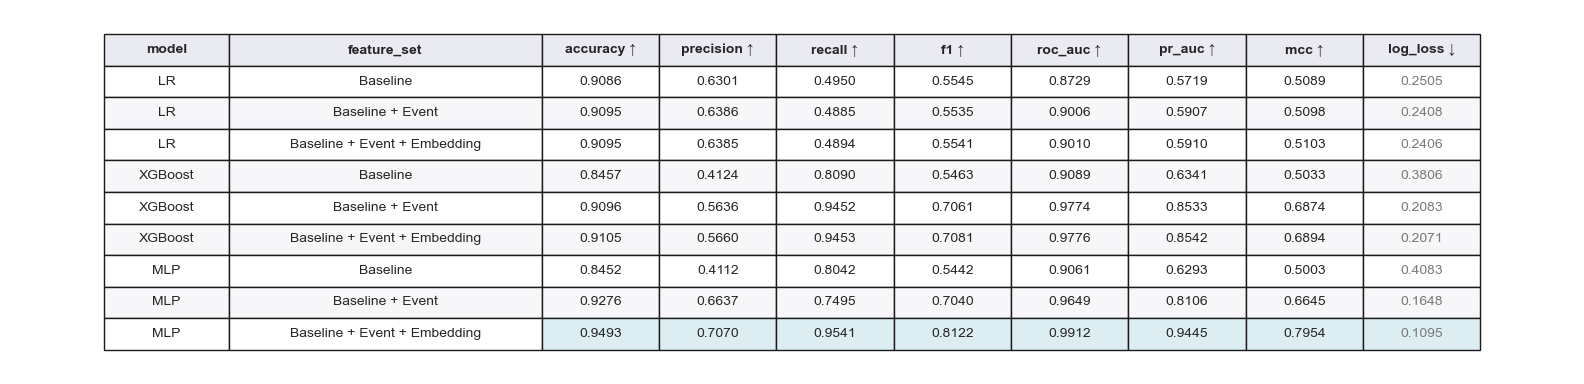

In [64]:
def normalize_metric_columns(df):
    return df.rename(columns={
        "Accuracy ↑": "accuracy",
        "Precision ↑": "precision",
        "Recall ↑": "recall",
        "F1 ↑": "f1",
        "ROC-AUC ↑": "roc_auc",
        "PR-AUC ↑": "pr_auc",
        "MCC ↑": "mcc",
        "Log Loss ↓": "log_loss"
    })

df_lr_clean = normalize_metric_columns(df_lr.copy())
df_xgb_clean = normalize_metric_columns(df_xgb.copy())
df_mlp_clean = normalize_metric_columns(df_mlp.copy())

df_lr_clean["model"] = "LR"
df_xgb_clean["model"] = "XGBoost"
df_mlp_clean["model"] = "MLP"

df_all = pd.concat(
    [df_lr_clean, df_xgb_clean, df_mlp_clean]
).reset_index().rename(columns={"index": "feature_set"})

cols = ["model", "feature_set", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "mcc", "log_loss"]

df_all["model"] = pd.Categorical(df_all["model"], ["LR", "XGBoost", "MLP"], ordered=True)
df_plot = df_all[cols].sort_values(["model", "feature_set"])

metric_direction = {
    "accuracy": "↑", "precision": "↑", "recall": "↑", "f1": "↑",
    "roc_auc": "↑", "pr_auc": "↑", "mcc": "↑", "log_loss": "↓"
}

df_plot = df_plot.rename(columns={k: f"{k} {v}" for k, v in metric_direction.items()})
df_num = df_all.copy().sort_values(["model", "feature_set"])

for c in df_plot.columns[2:]:
    df_plot[c] = df_plot[c].map(lambda x: f"{x:.4f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")

table = ax.table(
    cellText=df_plot.values,
    colLabels=df_plot.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for j in range(len(df_plot.columns)):
    table[0, j].set_facecolor("#EAEAF2")
    table[0, j].set_text_props(weight="bold")

for i in range(1, len(df_plot) + 1):
    color = "#F7F7FA" if i % 2 == 0 else "white"
    for j in range(len(df_plot.columns)):
        table[i, j].set_facecolor(color)

for i in range(len(df_plot) + 1):
    table[i, 0].set_width(0.08)
    table[i, 1].set_width(0.20)
    for j in range(2, len(df_plot.columns)):
        table[i, j].set_width(0.075)

logloss_idx = [i for i, c in enumerate(df_plot.columns) if "log_loss" in c][0]
for i in range(1, len(df_plot) + 1):
    table[i, logloss_idx].set_text_props(color="#7A7A7A")

for j, col in enumerate(cols[2:], start=2):
    idx = df_num[col].idxmax() if metric_direction[col] == "↑" else df_num[col].idxmin()
    row = list(df_num.index).index(idx) + 1
    table[row, j].set_facecolor("#DCEEF2")

plt.tight_layout()
plt.show()

In this table, the arrows next to each metric indicate the **optimization direction**: **↑ means higher values are better**, while **↓ means lower values are preferred** (e.g., log loss).

The cells highlighted in blue represent the **best-performing values for each metric across all configurations**. This highlighting helps quickly identify the strongest results without manually scanning the entire table.

Together, these annotations improve readability and allow for more efficient comparison of model performance across different settings.

#### 5.4.1.1 Model-level comparison
To analyze model performance more comprehensively, we compare the distribution of scores across multiple evaluation metrics using **box plots**. Each subplot corresponds to a specific metric, while each box represents the performance distribution of a model across different feature configurations.

This visualization is chosen because it captures not only the **central tendency (median performance)** but also the **variability and stability** of each model. Compared to single-value comparisons, box plots provide a clearer understanding of how consistently each model performs across different experimental settings.

By examining multiple metrics simultaneously, this approach allows us to assess both the **overall strength** and the **robustness** of each model.

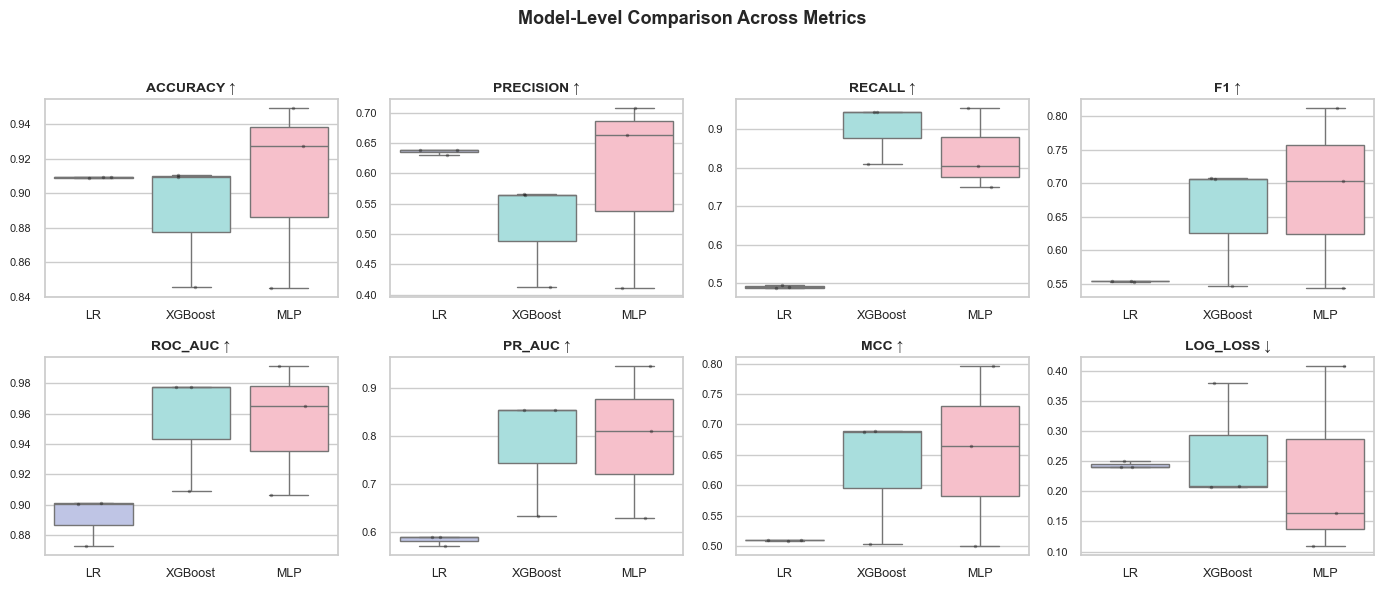

In [65]:
sns.set_style("whitegrid")

metrics_up=["accuracy","precision","recall","f1","roc_auc","pr_auc","mcc"]
metrics_down=["log_loss"]
all_metrics=metrics_up+metrics_down

df_long=df_all.melt(id_vars=["model","feature_set"],value_vars=all_metrics,
                    var_name="metric",value_name="score")
df_long["model"]=pd.Categorical(df_long["model"],["LR","XGBoost","MLP"],ordered=True)

palette={"LR":"#B8C1EC","XGBoost":"#A0E7E5","MLP":"#FFB7C5"}

fig,axs=plt.subplots(2,4,figsize=(14,6)); axs=axs.flatten()

for ax,m in zip(axs,all_metrics):
    d=df_long[df_long["metric"]==m]
    sns.boxplot(data=d,x="model",y="score",hue="model",palette=palette,
                dodge=False,fliersize=0,linewidth=1,legend=False,ax=ax)
    sns.stripplot(data=d,x="model",y="score",color="black",
                  size=2.5,alpha=0.35,jitter=0.2,ax=ax)

    arrow="↑" if m in metrics_up else "↓"
    ax.set_title(f"{m.upper()} {arrow}",fontsize=10,weight="bold")

    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis='x',labelsize=9); ax.tick_params(axis='y',labelsize=8)

for ax in axs[len(all_metrics):]: ax.axis("off")

plt.suptitle("Model-Level Comparison Across Metrics",fontsize=13,weight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

From the figure, **MLP consistently achieves the highest median performance across most metrics**, indicating its strong overall capability. It also shows relatively wide distributions in some metrics, suggesting that while it performs well, its performance may vary depending on the feature configuration.

**XGBoost demonstrates competitive performance**, often ranking second across metrics such as F1, ROC-AUC, and MCC. Its distributions are generally more compact, indicating **more stable and consistent behavior** across different feature sets.

In contrast, **Logistic Regression (LR) performs significantly worse**, particularly in recall, F1 score, and MCC. Its limited variation reflects a more constrained modeling capacity, as it cannot capture complex nonlinear patterns in the data.

#### 5.4.1.2 Feature-level comparison

To evaluate the impact of feature design on model performance, we compare results across different **feature sets** using a grouped bar chart. Each group represents a feature configuration (Baseline, Baseline + Event, and Full), while different colors indicate different models.

We focus on **F1 score** as the primary metric, as it provides a balanced measure of precision and recall, which is particularly important for this task. This visualization allows us to clearly observe how performance changes as additional features are introduced.

Compared to more complex visualizations, the grouped bar chart offers a **direct and intuitive comparison**, making it easy to identify performance improvements across feature configurations for each model.

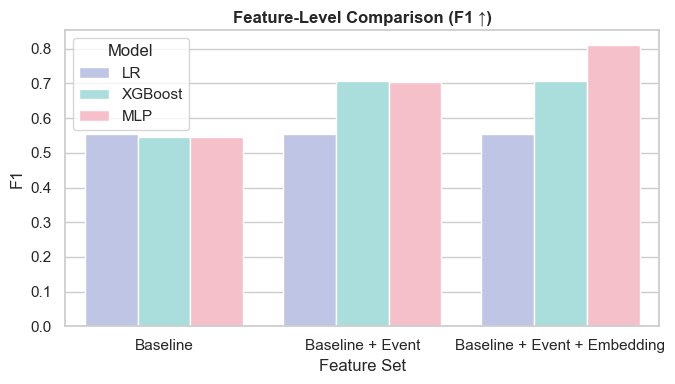

In [66]:
sns.set_style("whitegrid")
metric = "f1"
plt.figure(figsize=(7,4))
palette = {
    "LR": "#B8C1EC",
    "XGBoost": "#A0E7E5",
    "MLP": "#FFB7C5"
}
sns.barplot(
    data=df_all,
    x="feature_set",
    y=metric,
    hue="model",
    palette=palette
)
plt.title(f"Feature-Level Comparison ({metric.upper()} ↑)", fontsize=12, weight="bold")
plt.xlabel("Feature Set")
plt.ylabel(metric.upper())
plt.legend(title="Model")
plt.tight_layout()
plt.show()

From the figure, it is clear that **model performance consistently improves as more features are incorporated**.

Using only the **baseline features**, all models achieve relatively similar performance, indicating that basic user-level features provide limited predictive power.

When **event-level features are added**, there is a noticeable improvement across all models, especially for **XGBoost and MLP**. This suggests that detailed behavioral and temporal information contributes significantly to the model’s ability to distinguish between classes.

The best performance is achieved with the **full feature set (Baseline + Event + Embedding)**. In particular, **MLP shows the largest gain**, indicating that it benefits the most from richer and higher-dimensional feature representations.

Overall, this comparison demonstrates that **feature engineering plays a critical role**, and that combining multiple levels of information leads to substantial improvements in model performance.

#### 5.4.1.3 Metric-level comparison

To analyze model performance across different evaluation criteria, we visualize the results using a **line plot with filled areas**. Each line represents a model, and each point corresponds to its average performance on a specific metric.

This visualization is chosen because it effectively captures the **overall performance profile** of each model across multiple metrics. Compared to bar charts, it highlights **patterns and trends**, allowing for easier comparison of strengths and weaknesses across evaluation dimensions.

The shaded area further enhances readability by emphasizing the relative magnitude of scores, making it easier to identify which models consistently perform better.

C:\Users\caiyf\AppData\Local\Temp\ipykernel_26944\2612120722.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_avg=df_all.groupby("model")[metrics].mean()


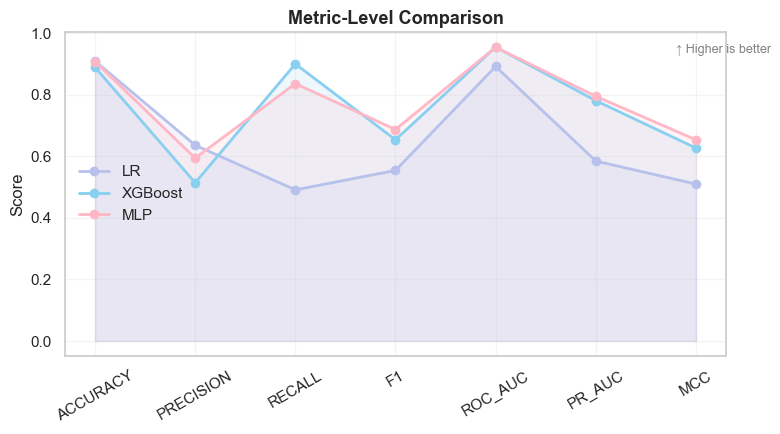

In [67]:
sns.set_style("whitegrid")
metrics=["accuracy","precision","recall","f1","roc_auc","pr_auc","mcc"]
df_avg=df_all.groupby("model")[metrics].mean()
colors={"LR":"#B8C1EC","XGBoost":"#89CFF0","MLP":"#FFB7C5"}
x=np.arange(len(metrics))

plt.figure(figsize=(8,4.5))
for m in df_avg.index:
    y=df_avg.loc[m].values
    plt.plot(x,y,marker='o',lw=2,label=m,color=colors[m])
    plt.fill_between(x,y,alpha=0.15,color=colors[m])

plt.xticks(x,[m.upper() for m in metrics],rotation=30)
plt.ylabel("Score"); plt.title("Metric-Level Comparison",fontsize=13,weight="bold")
plt.text(len(metrics)-1.2,max(df_avg.max())*0.98,"↑ Higher is better",fontsize=9,color="gray")
plt.legend(frameon=False); plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()

From the figure, **MLP consistently outperforms the other models across most metrics**, indicating its strong ability to capture complex patterns in the data. Its advantage is particularly evident in **F1 score, ROC-AUC, PR-AUC and MCC**, suggesting better overall classification quality.

**XGBoost shows competitive performance**, especially in ranking-based metrics such as ROC-AUC, but generally remains slightly below MLP. Its performance is relatively stable across metrics.

In contrast, **Logistic Regression (LR) performs significantly worse**, particularly in recall and F1 score. This indicates that linear models struggle to capture the complexity of the task.

A notable pattern is that all models achieve relatively high **ROC-AUC**, while performance on **F1** is lower. This suggests that although the models can rank predictions well, they face challenges in making accurate positive classifications under a fixed threshold.

Overall, the metric-level comparison highlights that **MLP provides the most balanced and consistently strong performance**, while also revealing important trade-offs across evaluation metrics.

### 5.4.2 Threshold Tuning Case Study

Based on the overall comparison in Section 5.4.1, we select **MLP with Baseline + Event features** as the representative model for a more detailed threshold tuning analysis. Since this model achieves the strongest F1 performance among the evaluated configurations, it provides a meaningful case for studying how classification decisions change under different thresholds.

In this visualization, the **classification threshold is manually adjustable** using the slider. As the threshold changes, the predicted class labels are updated accordingly, which directly affects the **confusion matrix** and the key threshold-dependent metrics: **accuracy, precision, recall, and F1 score**.

The dashboard also includes the **ROC curve** and the current threshold point on the curve. While **ROC-AUC** is used as one of the main evaluation metrics, the ROC-AUC value itself does not change with the threshold; instead, the threshold determines the specific operating point on the ROC curve.

For clarity, this section focuses on the five basic metrics used in the main evaluation: **accuracy, precision, recall, F1 score, and ROC-AUC**.

In [68]:
def notebook_threshold_tuner_final(y_true, y_score, model_name="Model", max_points=500, random_state=42):
    plt.ioff(); plt.close("all")
    y_true, y_score = np.asarray(y_true).reshape(-1), np.asarray(y_score).reshape(-1)
    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_score); roc_auc = roc_auc_score(y_true, y_score)

    rows = []
    for t in np.round(np.linspace(0, 1, 101), 2):
        yp = (y_score >= t).astype(int); tn, fp, fn, tp = confusion_matrix(y_true, yp).ravel()
        rows.append(dict(threshold=t, accuracy=accuracy_score(y_true, yp),
                         precision=precision_score(y_true, yp, zero_division=0),
                         recall=recall_score(y_true, yp, zero_division=0),
                         f1=f1_score(y_true, yp, zero_division=0),
                         TP=tp, FP=fp, FN=fn, TN=tn,
                         current_fpr=fp/(fp+tn) if fp+tn > 0 else 0,
                         current_tpr=recall_score(y_true, yp, zero_division=0)))
    df_thr = pd.DataFrame(rows)

    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(y_score), size=min(max_points, len(y_score)), replace=False)
    ys, yt = y_score[idx], y_true[idx]

    n_bins = 45; bins = np.linspace(0, 1, n_bins + 1)
    bid = np.clip(np.digitize(ys, bins) - 1, 0, n_bins - 1)
    xp, yp = ys.copy(), np.zeros_like(ys, dtype=float)

    for b in range(n_bins):
        ii = np.where(bid == b)[0]; n = len(ii)
        if n == 0: continue
        left, right = bins[b], bins[b+1]; center, width = (left+right)/2, right-left
        nc, nr = int(np.ceil(np.sqrt(n))), int(np.ceil(n/np.ceil(np.sqrt(n))))
        rp, cp = np.arange(n)//nc, np.arange(n)%nc
        xo = (cp/(nc-1)-0.5)*width*0.78 if nc > 1 else np.zeros(n)
        yv = 0.06 + (rp/(nr-1))*0.78 if nr > 1 else np.full(n, 0.08)
        xp[ii] = np.clip(center + xo + rng.normal(0, width*0.035, n), 0, 1)
        yp[ii] = np.clip(yv + rng.normal(0, 0.012, n), 0.04, 0.90)

    slider = widgets.FloatSlider(value=0.50, min=0, max=1, step=0.01, description="Threshold:",
                                 continuous_update=True, readout=True, readout_format=".2f",
                                 layout=widgets.Layout(width="700px"))
    image_widget = widgets.Image(format="png", layout=widgets.Layout(width="780px"))

    bg, panel = "#F7F5F0", "#FAF9F6"
    neg_bg, pos_bg = "#F3E6C9", "#C9B7E8"
    neg_c, pos_c, err_c = "#D8A24A", "#8F7AAE", "#B76E79"
    text_c, muted_c, line_c, point_c, grid_c, border_c = "#3F3F3F", "#666666", "#7E9AAF", "#B76E79", "#D8D3CC", "#4A4A4A"

    def draw(change=None):
        t = round(slider.value, 2); row = df_thr.iloc[int(round(t*100))]
        pred = (ys >= t).astype(int); err = pred != yt; neg, pos = pred == 0, pred == 1

        fig = Figure(figsize=(12, 6.2), facecolor=bg)
        gs = fig.add_gridspec(2, 3, height_ratios=[0.9, 1.25], width_ratios=[1.25, 1.0, 1.2], hspace=0.45, wspace=0.32)

        ax = fig.add_subplot(gs[0, :]); ax.set_facecolor(panel)
        ax.axvspan(0, t, color=neg_bg, alpha=0.85); ax.axvspan(t, 1, color=pos_bg, alpha=0.85)
        ax.axvline(t, color="#2F2F2F", linewidth=3, alpha=0.95, zorder=2)
        ax.scatter(xp[neg], yp[neg], s=70, marker="o", c=neg_c, edgecolor="white", linewidth=0.8, alpha=0.9, zorder=3, label="Predicted negative")
        ax.scatter(xp[pos], yp[pos], s=70, marker="s", c=pos_c, edgecolor="white", linewidth=0.8, alpha=0.9, zorder=3, label="Predicted positive")
        ax.scatter(xp[err], yp[err], s=120, marker="x", c=err_c, linewidth=2.6, alpha=0.98, zorder=4, label="Misclassified")
        ax.scatter([t], [0.50], s=260, facecolors="none", edgecolors="#2F2F2F", linewidth=2.4, zorder=5)
        ax.set_title("Classification Threshold", fontsize=15, loc="left", pad=10, color=text_c)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_yticks([]); ax.set_xlabel("")
        ax.tick_params(axis="x", colors=muted_c, labelsize=9)
        for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
        ax.spines["bottom"].set_color("#B8B0A8")

        ax = fig.add_subplot(gs[1, 0]); ax.set_facecolor(panel); ax.axis("off")
        ax.set_title("Confusion Matrix", fontsize=15, loc="left", pad=14, color=text_c)
        ax.set_xlim(0, 3); ax.set_ylim(-0.2, 2.25)

        for x, y, c in [(1,1,pos_bg),(2,1,pos_bg),(1,0.25,neg_bg),(2,0.25,neg_bg)]:
            ax.add_patch(Rectangle((x, y), 1, 0.75, facecolor=c, edgecolor=border_c, linewidth=1.3))
        for y in [1.75, 1.0, 0.25]: ax.plot([1, 3], [y, y], color=border_c, linewidth=1.3)
        for x in [1, 2, 3]: ax.plot([x, x], [0.25, 2.05], color=border_c, linewidth=1.3)

        for x, y, txt in [(1.5,1.98,"Actually\npositive"),(2.5,1.98,"Actually\nnegative"),(0.48,1.375,"Predicted\npositive"),(0.48,0.625,"Predicted\nnegative")]:
            ax.text(x, y, txt, ha="center", va="center", fontsize=10.5, color=text_c)

        cells = [("TP",1.5,1.375,"s",pos_c,False,"white"),("FP",2.5,1.375,"s",pos_c,True,"white"),
                 ("FN",1.5,0.625,"o",neg_c,True,pos_c),("TN",2.5,0.625,"o",neg_c,False,pos_c)]
        for name, x, y, marker, color, wrong, tc in cells:
            ax.scatter(x, y+0.10, s=620, marker=marker, color=color, edgecolor="white", linewidth=1.4, zorder=4)
            if wrong: ax.scatter(x, y+0.10, s=310, marker="x", color=err_c, linewidth=3.0, zorder=5)
            ax.text(x, y-0.17, f"{name}={int(row[name])}", ha="center", va="center", fontsize=10, fontweight="bold", color=tc)

        ax = fig.add_subplot(gs[1, 1]); ax.set_facecolor(panel); ax.axis("off")
        ax.set_title("Metrics", fontsize=15, pad=16, color=text_c)
        for name, value, y in zip(["Accuracy","Precision","Recall","F1"], [row.accuracy,row.precision,row.recall,row.f1], [0.75,0.58,0.41,0.24]):
            ax.text(0.08, y, name, fontsize=12.5, ha="left", va="center", color=text_c)
            ax.text(0.78, y, f"{value:.2f}", fontsize=12.5, ha="right", va="center", fontweight="bold", color=text_c)

        ax = fig.add_subplot(gs[1, 2]); ax.set_facecolor(panel)
        ax.plot(fpr_curve, tpr_curve, linewidth=2.3, color=line_c, label=f"ROC-AUC = {roc_auc:.2f}")
        ax.scatter(row.current_fpr, row.current_tpr, s=85, color=point_c, edgecolor="white", linewidth=1.3, zorder=5, label="Current threshold")
        ax.plot([0,1], [0,1], "--", linewidth=1.2, color="#B8B0A8", alpha=0.8)
        ax.set_title("ROC Curve", fontsize=15, pad=16, color=text_c)
        ax.set_xlabel("False Positive Rate", fontsize=10.5, color=text_c); ax.set_ylabel("True Positive Rate", fontsize=10.5, color=text_c)
        ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.grid(alpha=0.45, color=grid_c); ax.tick_params(colors=muted_c, labelsize=9)
        for s in ax.spines.values(): s.set_color("#CFC8BF")
        ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="#DDD6CE", fontsize=9)

        fig.suptitle(f"{model_name}: Threshold Tuning", fontsize=16, y=0.98, color=text_c)
        buf = io.BytesIO(); fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
        image_widget.value = buf.getvalue(); buf.close()

    display(widgets.VBox([image_widget, slider]))
    draw()
    slider.observe(draw, names="value")

notebook_threshold_tuner_final(
    y_true=np.asarray(y_test),
    y_score=np.asarray(y_scores_mlp["Baseline + Event"]).reshape(-1),
    model_name="MLP - Baseline + Event",
    max_points=555
)

## The plot above may not display automatically. The cell may need to be re-run with the required data and packages available.

From the threshold tuning visualization, we can observe how changing the threshold affects the trade-off between **precision** and **recall**. A higher threshold makes the model more conservative when predicting positive cases, while a lower threshold makes the model more likely to classify users as positive.

In this task, the target is **purchase vs. not purchase**, and the dataset is naturally **imbalanced**, with **not purchase** being the majority class. Because positive purchase cases are relatively less common, using a low threshold may lead to many users being incorrectly predicted as purchasers, increasing the number of **false positives**. Therefore, a higher threshold can be more appropriate, because the model only predicts purchase when it has stronger confidence.

In this selected case, the threshold is adjusted to around **0.81**, where the model achieves an **F1 score of approximately 0.87**. This suggests that the higher threshold provides a better balance between **precision** and **recall** for this imbalanced classification task. At this operating point, the model maintains strong overall performance, with **accuracy, precision, and recall** all remaining at relatively high levels.

The confusion matrix further shows that the model is able to correctly identify a large number of positive and negative cases while controlling both false positives and false negatives. This is important because **F1 score** depends on both precision and recall, rather than only overall accuracy.

Overall, this threshold tuning analysis shows that the final classification performance is not determined only by the model itself, but also by the chosen decision threshold. For an imbalanced purchase prediction task, selecting an appropriate threshold is especially important, since the default threshold of **0.50** may not provide the best balance between identifying true purchasers and avoiding false purchase predictions.

### 5.4.3 Task-Specific Metric Analysis


#### 5.4.3.1 PR-AUC Analysis

To further evaluate model performance under the **purchase prediction** setting, we analyze **PR-AUC** as a task-specific metric. Since the dataset is imbalanced and **purchase** is the minority class, PR-AUC is especially useful because it focuses on the trade-off between **precision** and **recall** for the positive class.

In this section, we compare the **Precision–Recall curves** of **LR**, **XGBoost**, and **MLP** using the same feature configuration: **Baseline + Event + Embedding**. The dashed horizontal line represents the positive-class baseline, which corresponds to the purchase rate in the dataset. A model performs better when its PR curve stays further above this baseline and closer to the upper-right region.

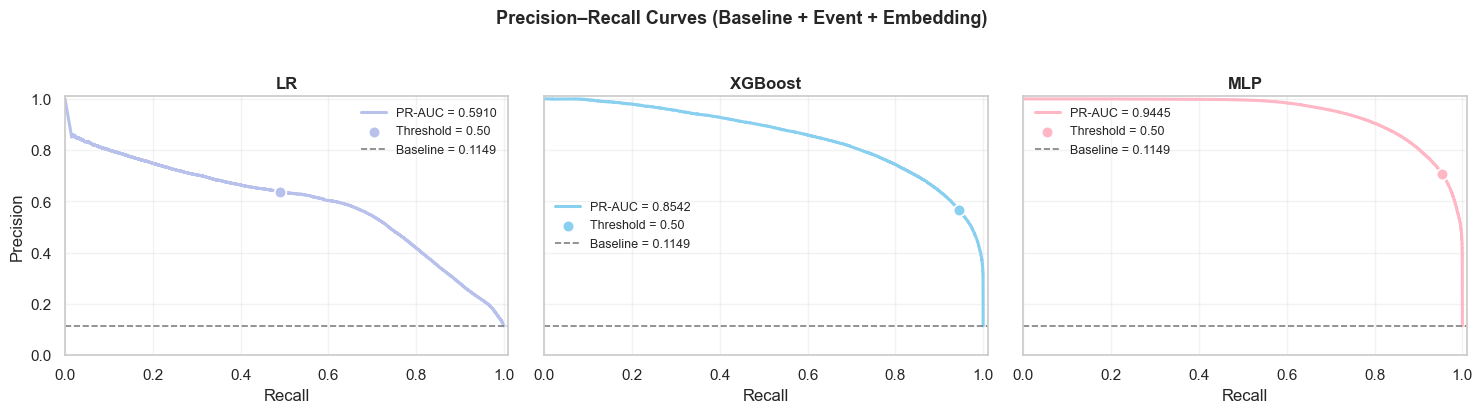

In [69]:
feat="Baseline + Event + Embedding"
scores={"LR":y_scores_lr[feat],"XGBoost":y_scores_xgb[feat],"MLP":y_scores_mlp[feat]}
ths={"LR":0.5,"XGBoost":0.5,"MLP":0.5}
colors={"LR":"#B8C1EC","XGBoost":"#89CFF0","MLP":"#FFB7C5"}

y_true=np.asarray(y_test).reshape(-1); pos=y_true.mean()
fig,axs=plt.subplots(1,3,figsize=(15,4.2),sharex=True,sharey=True)

for ax,(name,score) in zip(axs,scores.items()):
    y_score=np.asarray(score).reshape(-1)
    p,r,_=precision_recall_curve(y_true,y_score)
    auc=average_precision_score(y_true,y_score)
    t=ths[name]; y_pred=(y_score>=t).astype(int)
    tp=((y_pred==1)&(y_true==1)).sum(); fp=((y_pred==1)&(y_true==0)).sum(); fn=((y_pred==0)&(y_true==1)).sum()
    pt=tp/(tp+fp) if tp+fp>0 else 0; rt=tp/(tp+fn) if tp+fn>0 else 0

    ax.plot(r,p,lw=2.2,color=colors[name],label=f"PR-AUC = {auc:.4f}")
    ax.scatter(rt,pt,s=70,color=colors[name],edgecolor="white",linewidth=1.2,zorder=5,label=f"Threshold = {t:.2f}")
    ax.axhline(pos,ls="--",lw=1.2,color="gray",label=f"Baseline = {pos:.4f}")
    ax.set_title(name,fontsize=12,weight="bold")
    ax.set_xlabel("Recall")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False,fontsize=9)

axs[0].set_ylabel("Precision")
for ax in axs: ax.set_xlim(0,1.01); ax.set_ylim(0,1.01)
plt.suptitle(f"Precision–Recall Curves ({feat})",fontsize=13,weight="bold")
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

From the Precision–Recall curves, **MLP achieves the strongest task-specific performance**, with the highest **PR-AUC of 0.9474**. Its curve remains close to the top of the plot across a wide range of recall values, showing that the model can identify many purchase cases while still maintaining high precision.

**XGBoost also performs well**, achieving a PR-AUC of **0.8542**, but its precision drops more quickly as recall increases. This suggests that XGBoost is effective at detecting positive cases, but it introduces more false positives than MLP when trying to recover more purchasers.

In contrast, **Logistic Regression has a much lower PR-AUC of 0.5911**, and its curve declines more substantially as recall increases. This indicates that LR struggles more with positive-class detection, which is expected given its simpler linear structure.

Overall, this analysis confirms that **MLP is the most effective model for the imbalanced purchase prediction task**, not only in general metrics but also in the task-specific goal of accurately identifying potential purchasers.

#### 5.4.3.2 MCC Analysis

To further evaluate classification quality under class imbalance, we analyze **Matthews Correlation Coefficient (MCC)** across different decision thresholds. MCC is a balanced metric that considers all four components of the confusion matrix: **TP, TN, FP, and FN**.

Unlike accuracy, MCC is less affected by the majority class and is therefore more suitable for the **purchase prediction** task, where **not purchase** cases dominate the dataset. By plotting MCC against threshold, we can observe how each model’s overall classification reliability changes as the decision boundary becomes more or less strict.

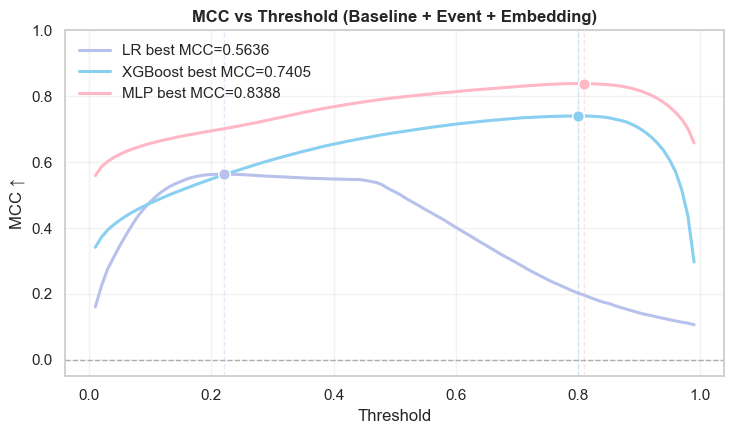

In [70]:
feat="Baseline + Event + Embedding"
scores={"LR":y_scores_lr[feat],"XGBoost":y_scores_xgb[feat],"MLP":y_scores_mlp[feat]}
colors={"LR":"#B8C1EC","XGBoost":"#89CFF0","MLP":"#FFB7C5"}

y_true=np.asarray(y_test).reshape(-1)
thresholds=np.linspace(0.01,0.99,99)

plt.figure(figsize=(7.5,4.5))

for name,score in scores.items():
    y_score=np.asarray(score).reshape(-1)
    mccs=[matthews_corrcoef(y_true,(y_score>=t).astype(int)) for t in thresholds]
    best_i=np.argmax(mccs)

    plt.plot(thresholds,mccs,lw=2.2,color=colors[name],label=f"{name} best MCC={mccs[best_i]:.4f}")
    plt.scatter(thresholds[best_i],mccs[best_i],s=70,color=colors[name],edgecolor="white",zorder=5)
    plt.axvline(thresholds[best_i],ls="--",lw=1,alpha=0.35,color=colors[name])

plt.axhline(0,ls="--",lw=1,color="gray",alpha=0.6)
plt.title(f"MCC vs Threshold ({feat})",fontsize=12,weight="bold")
plt.xlabel("Threshold")
plt.ylabel("MCC ↑")
plt.ylim(-0.05,1.0)
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

From the MCC-threshold curve, **MLP achieves the highest best MCC score of 0.8441**, outperforming both **XGBoost** and **Logistic Regression**. This indicates that MLP provides the most balanced classification performance when considering true positives, true negatives, false positives, and false negatives together.

**XGBoost also performs strongly**, reaching a best MCC of **0.7402**, but it remains below MLP across most threshold values. In contrast, **Logistic Regression reaches a much lower best MCC of 0.5635**, showing its weaker ability to produce balanced predictions under class imbalance.

Another important observation is that the best MCC for both **MLP** and **XGBoost** occurs around a relatively high threshold, close to **0.8**. This is consistent with the earlier threshold tuning result: for this imbalanced purchase prediction task, the model needs a higher confidence level before predicting a user as a purchaser.

Overall, the MCC analysis confirms that **MLP is the most reliable model for balanced classification**, while also showing that threshold selection plays an important role in achieving strong performance.

#### 5.4.3.3 Log Loss Analysis

To evaluate the quality of predicted probabilities, we further analyze **log loss**. Unlike metrics such as F1 score or MCC, log loss does not depend on a fixed classification threshold. Instead, it evaluates how confident and accurate the model’s probability estimates are.

A lower log loss indicates that the model assigns higher probabilities to correct labels and avoids being overly confident on incorrect predictions. Therefore, log loss is especially useful for assessing whether a model’s predicted probabilities are reliable, rather than only whether its final class predictions are correct.

To visualize this, we use a **calibration curve**, which compares predicted probabilities with the actual observed positive rate. A well-calibrated model should have a curve close to the diagonal reference line.

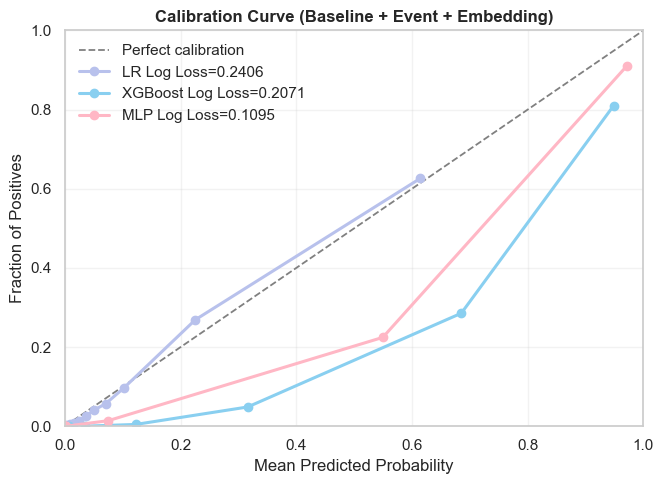

In [71]:
feat="Baseline + Event + Embedding"
scores={"LR":y_scores_lr[feat],"XGBoost":y_scores_xgb[feat],"MLP":y_scores_mlp[feat]}
colors={"LR":"#B8C1EC","XGBoost":"#89CFF0","MLP":"#FFB7C5"}

y_true=np.asarray(y_test).reshape(-1)

plt.figure(figsize=(6.8,5))
plt.plot([0,1],[0,1],"--",color="gray",lw=1.3,label="Perfect calibration")

for name,score in scores.items():
    y_score=np.asarray(score).reshape(-1)
    frac_pos,mean_pred=calibration_curve(y_true,y_score,n_bins=10,strategy="quantile")
    ll=log_loss(y_true,y_score)
    plt.plot(mean_pred,frac_pos,marker="o",lw=2.2,color=colors[name],label=f"{name} Log Loss={ll:.4f}")

plt.title(f"Calibration Curve ({feat})",fontsize=12,weight="bold")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.xlim(0,1); plt.ylim(0,1)
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

From the calibration curve, **MLP achieves the lowest log loss (0.1045)** among the three models, indicating that it provides the most reliable probability estimates overall. This means that MLP is less likely to make highly confident but incorrect probability predictions.

**XGBoost has a higher log loss (0.2075)** than MLP. Its calibration curve stays noticeably below the diagonal line in the middle-to-high probability range, which suggests that it may be **overestimating purchase probabilities** in some regions.

**Logistic Regression (LR) has the highest log loss (0.2404)** among the three models. Although part of its curve is relatively close to the diagonal line, its overall probability quality is weaker, which is consistent with its lower performance in previous classification metrics.

Overall, the log loss analysis shows that **MLP not only performs best in classification-based metrics, but also produces the most reliable probability scores**. This is important for the purchase prediction task because probability outputs may be used for ranking users, targeting potential purchasers, or supporting downstream decision-making.